# Discretizaciones

**Percentiles:** 50 y 100

**Interpolación:** 50 y 100

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

In [2]:
# --------------------------------------------------------------
# Fuentes definitivas para todas las discretizaciones
# --------------------------------------------------------------

ruta_catalogo = Path(
    "../data/interim/catalogo_maestro_final.csv"
)

ruta_curvas_plegadas = Path(
    "../data/interim/curvas_plegadas_final.parquet"
)

catalogo = pd.read_csv(
    ruta_catalogo
)

archivo_curvas_plegadas = pq.ParquetFile(
    ruta_curvas_plegadas
)


# --------------------------------------------------------------
# Verificación inequívoca de las fuentes cargadas
# --------------------------------------------------------------

conteos_curvas_corregidas = (
    catalogo.loc[
        catalogo["observacion_id"].isin({
            "OGLEIII_OGLE-LMC-RRLYR-14167",
            "OGLEIII_OGLE-LMC-RRLYR-17594",
        }),
        [
            "observacion_id",
            "n_obs_validas",
            "n_obs_folding",
        ],
    ]
    .sort_values(
        "observacion_id"
    )
    .reset_index(drop=True)
)

print(
    "Catálogo utilizado:",
    ruta_catalogo.resolve(),
)

print(
    "Parquet utilizado:",
    ruta_curvas_plegadas.resolve(),
)

print(
    "Catálogo encontrado:",
    ruta_catalogo.exists(),
)

print(
    "Parquet encontrado:",
    ruta_curvas_plegadas.exists(),
)

print(
    "Filas del catálogo:",
    f"{len(catalogo):,}",
)

print(
    "Filas del Parquet:",
    f"{archivo_curvas_plegadas.metadata.num_rows:,}",
)

print(
    "Mediciones según el catálogo:",
    f"{catalogo['n_obs_folding'].sum():,}",
)

print(
    "Grupos internos:",
    archivo_curvas_plegadas.num_row_groups,
)

display(
    conteos_curvas_corregidas
)

C:\Users\adanm\AppData\Local\Temp\ipykernel_8560\3122953499.py:13: DtypeWarning: Columns (0: transicion) have mixed types. Specify dtype option on import or set low_memory=False.
  catalogo = pd.read_csv(


Catálogo utilizado: C:\Users\adanm\Code\tesis\data\interim\catalogo_maestro_final.csv
Parquet utilizado: C:\Users\adanm\Code\tesis\data\interim\curvas_plegadas_final.parquet
Catálogo encontrado: True
Parquet encontrado: True
Filas del catálogo: 104,008
Filas del Parquet: 104,008
Mediciones según el catálogo: 132,232,695
Grupos internos: 105


,observacion_id,n_obs_validas,n_obs_folding
0,OGLEIII_OGLE-LMC-RRLYR-14167,771,771
1,OGLEIII_OGLE-LMC-RRLYR-17594,1027,1027


In [3]:
def racha_maxima_circular(vacios):
    """
    Calcula la mayor cantidad de intervalos vacíos consecutivos,
    considerando que el primero y el último son vecinos.
    """

    vacios = np.asarray(
        vacios,
        dtype=bool,
    )

    total = len(
        vacios
    )

    if not vacios.any():
        return 0

    if vacios.all():
        return total

    # Duplicamos el vector para detectar una racha que comience
    # al final del ciclo y continúe al principio.
    vacios_duplicados = np.concatenate([
        vacios,
        vacios,
    ])

    racha_actual = 0
    racha_maxima = 0

    for es_vacio in vacios_duplicados:

        if es_vacio:
            racha_actual += 1

            racha_maxima = max(
                racha_maxima,
                racha_actual,
            )

        else:
            racha_actual = 0

    return min(
        racha_maxima,
        total,
    )


def auditar_cobertura_fase(
    fase,
    resolucion,
):
    """
    Evalúa la cobertura de una curva plegada para una resolución
    determinada.

    Retorna la cantidad de intervalos vacíos, su porcentaje,
    la máxima racha circular vacía, la mayor separación entre
    fases observadas y la cantidad de fases duplicadas.
    """

    fase = np.asarray(
        fase,
        dtype=np.float64,
    )

    # Asignamos cada medición a uno de los intervalos regulares.
    indices = np.floor(
        fase * resolucion
    ).astype(int)

    indices = np.clip(
        indices,
        0,
        resolucion - 1,
    )

    conteos = np.bincount(
        indices,
        minlength=resolucion,
    )

    intervalos_vacios = (
        conteos == 0
    )

    # np.unique devuelve las fases ordenadas y permite contar
    # cuántas mediciones comparten exactamente la misma fase.
    fases_unicas = np.unique(
        fase
    )

    # Añadimos el primer punto desplazado una unidad para medir
    # también la separación circular entre el final y el inicio.
    fases_extendidas = np.concatenate([
        fases_unicas,
        [
            fases_unicas[0] + 1.0
        ],
    ])

    separaciones = np.diff(
        fases_extendidas
    )

    return {
        "resolucion":
            resolucion,
        "intervalos_vacios":
            int(
                intervalos_vacios.sum()
            ),
        "porcentaje_vacio":
            float(
                intervalos_vacios.mean()
                * 100
            ),
        "racha_vacia_maxima":
            racha_maxima_circular(
                intervalos_vacios
            ),
        "separacion_fase_maxima":
            float(
                separaciones.max()
            ),
        "fases_duplicadas":
            int(
                len(fase)
                - len(fases_unicas)
            ),
    }


# Leemos la primera curva desde el Parquet final.
# La variable correcta es archivo_curvas_plegadas,
# definida en la celda de carga.
tabla_ejemplo = (
    archivo_curvas_plegadas
    .read_row_group(
        0,
        columns=[
            "observacion_id",
            "fase",
        ],
    )
)

curva_ejemplo = (
    tabla_ejemplo
    .slice(
        0,
        1,
    )
    .to_pylist()[0]
)

auditoria_ejemplo = pd.DataFrame([
    auditar_cobertura_fase(
        curva_ejemplo["fase"],
        50,
    ),
    auditar_cobertura_fase(
        curva_ejemplo["fase"],
        100,
    ),
])

print(
    "Observación:",
    curva_ejemplo["observacion_id"],
)

print(
    "Mediciones:",
    len(
        curva_ejemplo["fase"]
    ),
)

display(
    auditoria_ejemplo
)

Observación: OGLEIII_OGLE-LMC-RRLYR-00001
Mediciones: 332


,resolucion,intervalos_vacios,porcentaje_vacio,racha_vacia_maxima,separacion_fase_maxima,fases_duplicadas
0,50,0,0.0,0,0.018043,0
1,100,6,6.0,1,0.018043,0


In [4]:
# Aquí se almacenarán las métricas calculadas para cada curva
# y para cada una de las dos resoluciones.
registros_cobertura = []

# Contador utilizado solamente para mostrar el avance.
curvas_procesadas = 0
total_curvas = archivo_curvas_plegadas.metadata.num_rows

# El Parquet se lee por grupos internos para evitar cargar
# simultáneamente las 132 millones de mediciones en memoria.
for numero_grupo in range(archivo_curvas_plegadas.num_row_groups):

    tabla_grupo = archivo_curvas_plegadas.read_row_group(
        numero_grupo,
        columns=["observacion_id", "fase"]
    )

    # Cada fila contiene un identificador y una lista de fases.
    filas_grupo = tabla_grupo.to_pylist()

    for fila in filas_grupo:

        observacion_id = fila["observacion_id"]
        fase = fila["fase"]

        # Se calcula la cobertura de la misma curva
        # utilizando 50 y 100 intervalos de fase.
        for resolucion in [50, 100]:

            metricas = auditar_cobertura_fase(
                fase,
                resolucion
            )

            registros_cobertura.append({
                "observacion_id": observacion_id,
                **metricas
            })

        curvas_procesadas += 1

    # Se informa el avance cada 20 grupos internos.
    if (
        (numero_grupo + 1) % 20 == 0
        or numero_grupo + 1 == archivo_curvas_plegadas.num_row_groups
    ):
        print(
            f"{curvas_procesadas:,} de "
            f"{total_curvas:,} curvas auditadas"
        )

# Se construye una tabla con dos filas por curva:
# una para resolución 50 y otra para resolución 100.
auditoria_cobertura = pd.DataFrame(
    registros_cobertura
)

# Resumen general por resolución.
resumen_cobertura = []

for resolucion, grupo in auditoria_cobertura.groupby(
    "resolucion"
):
    total_intervalos = len(grupo) * resolucion
    total_vacios = grupo["intervalos_vacios"].sum()

    resumen_cobertura.append({
        "resolucion": resolucion,
        "curvas_auditadas": len(grupo),
        "curvas_con_vacios": (
            grupo["intervalos_vacios"] > 0
        ).sum(),
        "porcentaje_curvas_con_vacios": (
            (grupo["intervalos_vacios"] > 0).mean()
            * 100
        ),
        "intervalos_vacios_totales": total_vacios,
        "porcentaje_intervalos_vacios": (
            total_vacios / total_intervalos * 100
        ),
        "mediana_intervalos_vacios": (
            grupo["intervalos_vacios"].median()
        ),
        "maximo_intervalos_vacios": (
            grupo["intervalos_vacios"].max()
        ),
        "maxima_racha_vacia": (
            grupo["racha_vacia_maxima"].max()
        ),
        "maxima_separacion_de_fase": (
            grupo["separacion_fase_maxima"].max()
        ),
        "curvas_con_fases_duplicadas": (
            grupo["fases_duplicadas"] > 0
        ).sum()
    })

resumen_cobertura = pd.DataFrame(
    resumen_cobertura
)

print(
    "\nFilas de auditoría:",
    f"{len(auditoria_cobertura):,}"
)

display(resumen_cobertura)

20,000 de 104,008 curvas auditadas
40,000 de 104,008 curvas auditadas
60,000 de 104,008 curvas auditadas
80,000 de 104,008 curvas auditadas
100,000 de 104,008 curvas auditadas
104,008 de 104,008 curvas auditadas

Filas de auditoría: 208,016


,resolucion,curvas_auditadas,curvas_con_vacios,porcentaje_curvas_con_vacios,intervalos_vacios_totales,porcentaje_intervalos_vacios,mediana_intervalos_vacios,maximo_intervalos_vacios,maxima_racha_vacia,maxima_separacion_de_fase,curvas_con_fases_duplicadas
0,50,104008,902,0.867241,1244,0.023921,0.0,25,22,0.461695,2984
1,100,104008,35082,33.730098,78229,0.752144,0.0,55,45,0.461695,2984


In [5]:
# Se incorporan metadatos del catálogo para saber a qué
# proyecto, región y subtipo pertenece cada curva auditada.
columnas_contexto = [
    "observacion_id",
    "proyecto_origen",
    "region_origen",
    "subtipo_rrlyrae",
    "n_obs_folding",
    "grupo_analisis"
]

auditoria_detallada = auditoria_cobertura.merge(
    catalogo[columnas_contexto],
    on="observacion_id",
    how="left",
    validate="many_to_one"
)

# Se resumen distintos niveles de porcentaje faltante.
umbrales_porcentaje = [1, 5, 10, 20, 40]
registros_umbrales = []

for resolucion, grupo in auditoria_detallada.groupby(
    "resolucion"
):
    for umbral in umbrales_porcentaje:
        cantidad = (
            grupo["porcentaje_vacio"] >= umbral
        ).sum()

        registros_umbrales.append({
            "resolucion": resolucion,
            "porcentaje_vacio_minimo": umbral,
            "curvas_afectadas": cantidad,
            "porcentaje_de_curvas": (
                cantidad / len(grupo) * 100
            )
        })

resumen_umbrales = pd.DataFrame(
    registros_umbrales
)

# También se revisa la distribución de la mayor separación
# circular entre dos fases observadas consecutivas.
resumen_separaciones = (
    auditoria_detallada
    .groupby("resolucion")[
        "separacion_fase_maxima"
    ]
    .quantile([0.50, 0.90, 0.95, 0.99, 0.999, 1.00])
    .unstack()
    .rename(
        columns={
            0.50: "mediana",
            0.90: "p90",
            0.95: "p95",
            0.99: "p99",
            0.999: "p99_9",
            1.00: "maximo"
        }
    )
    .reset_index()
)

# Las separaciones de fase no dependen de la resolución.
# Se muestran las curvas con los mayores huecos observacionales,
# utilizando una sola fila por observación.
curvas_mayores_huecos = (
    auditoria_detallada[
        auditoria_detallada["resolucion"] == 100
    ]
    .sort_values(
        "separacion_fase_maxima",
        ascending=False
    )
    .head(15)
    [
        [
            "observacion_id",
            "proyecto_origen",
            "region_origen",
            "subtipo_rrlyrae",
            "n_obs_folding",
            "intervalos_vacios",
            "porcentaje_vacio",
            "racha_vacia_maxima",
            "separacion_fase_maxima"
        ]
    ]
)

print("Curvas según porcentaje mínimo de intervalos vacíos:")
display(resumen_umbrales)

print("\nDistribución de la separación máxima entre fases:")
display(resumen_separaciones)

print("\nCurvas con los mayores huecos de fase:")
display(curvas_mayores_huecos)

Curvas según porcentaje mínimo de intervalos vacíos:


,resolucion,porcentaje_vacio_minimo,curvas_afectadas,porcentaje_de_curvas
0,50,1,902,0.867241
1,50,5,49,0.047112
2,50,10,35,0.033651
3,50,20,11,0.010576
4,50,40,1,0.000961
5,100,1,35082,33.730098
6,100,5,2972,2.857473
7,100,10,82,0.078840
8,100,20,25,0.024037
9,100,40,1,0.000961



Distribución de la separación máxima entre fases:


,resolucion,mediana,p90,p95,p99,p99_9,maximo
0,50,0.010917,0.018018,0.020215,0.025074,0.034167,0.461695
1,100,0.010917,0.018018,0.020215,0.025074,0.034167,0.461695



Curvas con los mayores huecos de fase:


,observacion_id,proyecto_origen,region_origen,subtipo_rrlyrae,n_obs_folding,intervalos_vacios,porcentaje_vacio,racha_vacia_maxima,separacion_fase_maxima
97761,OGLEIV_OGLE-LMC-RRLYR-06946,OGLE-IV,LMC,RRab,318,55,55.0,45,0.461695
13287,OGLEIII_OGLE-LMC-RRLYR-06946,OGLE-III,LMC,RRab,536,29,29.0,24,0.252638
94905,OGLEIV_OGLE-LMC-RRLYR-05375,OGLE-IV,LMC,RRab,437,26,26.0,23,0.236559
142613,OGLEIV_OGLE-LMC-RRLYR-35509,OGLE-IV,LMC,RRab,481,27,27.0,22,0.221333
182621,OGLEIV_OGLE-BLG-RRLYR-30677,OGLE-IV,BLG,RRab,601,21,21.0,19,0.206873
101243,OGLEIV_OGLE-LMC-RRLYR-08884,OGLE-IV,LMC,RRc,733,27,27.0,19,0.206842
103091,OGLEIV_OGLE-LMC-RRLYR-09910,OGLE-IV,LMC,RRc,733,30,30.0,19,0.199212
99585,OGLEIV_OGLE-LMC-RRLYR-07944,OGLE-IV,LMC,RRab,772,28,28.0,18,0.195493
86253,OGLEIV_OGLE-LMC-RRLYR-00580,OGLE-IV,LMC,RRc,425,22,22.0,17,0.180999
10243,OGLEIII_OGLE-LMC-RRLYR-05375,OGLE-III,LMC,RRab,378,25,25.0,17,0.179513


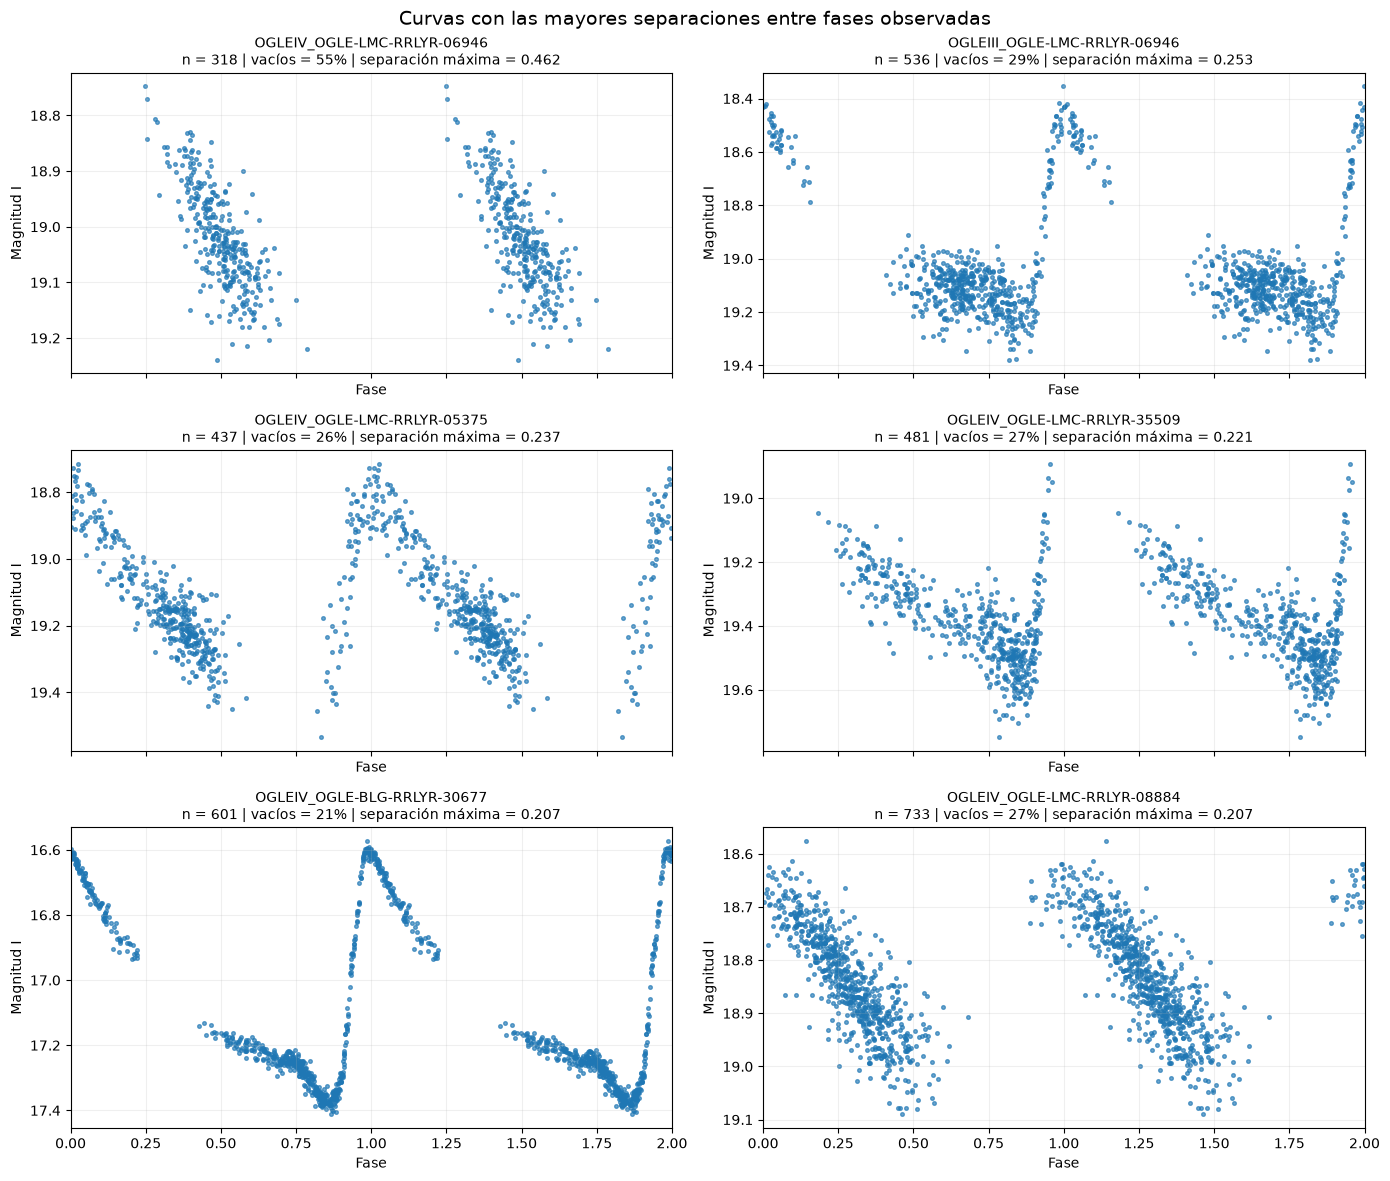

Parquet utilizado: C:\Users\adanm\Code\tesis\data\interim\curvas_plegadas_final.parquet
Filas del Parquet: 104,008
Curvas representadas: 6


In [6]:
# --------------------------------------------------------------
# Restablecimiento explícito de la fuente definitiva
# --------------------------------------------------------------

# Esta asignación protege el resto del notebook frente a cualquier
# ruta antigua que haya quedado almacenada en el kernel.
ruta_curvas_plegadas = Path(
    "../data/interim/curvas_plegadas_final.parquet"
)

archivo_curvas_plegadas = pq.ParquetFile(
    ruta_curvas_plegadas
)

if not ruta_curvas_plegadas.exists():
    raise FileNotFoundError(
        "No se encontró curvas_plegadas_final.parquet."
    )

if (
    archivo_curvas_plegadas.metadata.num_rows
    != 104_008
):
    raise ValueError(
        "El Parquet final no contiene 104.008 curvas."
    )


# --------------------------------------------------------------
# Selección de las curvas extremas
# --------------------------------------------------------------

# auditoria_detallada contiene dos filas por observación,
# correspondientes a las resoluciones 50 y 100.
#
# Después de ordenar por la máxima separación de fase,
# conservamos una sola fila por observación.
ids_extremos = (
    auditoria_detallada
    .sort_values(
        "separacion_fase_maxima",
        ascending=False,
    )
    .drop_duplicates(
        "observacion_id"
    )
    .head(6)[
        "observacion_id"
    ]
    .tolist()
)


# --------------------------------------------------------------
# Lectura de las seis curvas desde el Parquet final
# --------------------------------------------------------------

tabla_extremos = pq.read_table(
    ruta_curvas_plegadas,
    columns=[
        "observacion_id",
        "fase",
        "magnitud",
        "error",
        "n_obs_folding",
    ],
    filters=[
        (
            "observacion_id",
            "in",
            ids_extremos,
        )
    ],
)

curvas_extremas = (
    tabla_extremos
    .to_pandas()
)


# --------------------------------------------------------------
# Orden de presentación
# --------------------------------------------------------------

# pq.read_table no garantiza que las curvas filtradas queden en el
# mismo orden que ids_extremos. Creamos un índice auxiliar para
# recuperar el orden del diagnóstico.
orden_extremos = {
    observacion_id: posicion
    for posicion, observacion_id
    in enumerate(
        ids_extremos
    )
}

curvas_extremas[
    "orden_grafico"
] = (
    curvas_extremas[
        "observacion_id"
    ]
    .map(
        orden_extremos
    )
)

curvas_extremas = (
    curvas_extremas
    .sort_values(
        "orden_grafico"
    )
    .reset_index(
        drop=True
    )
)


# --------------------------------------------------------------
# Construcción del gráfico
# --------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 12),
    sharex=True,
)

axes = axes.ravel()


for ax, (_, fila) in zip(
    axes,
    curvas_extremas.iterrows(),
):

    fase = np.asarray(
        fila["fase"],
        dtype=np.float64,
    )

    magnitud = np.asarray(
        fila["magnitud"],
        dtype=np.float64,
    )

    # La duplicación se realiza únicamente para visualizar
    # dos ciclos consecutivos. No modifica los datos almacenados.
    fase_doble = np.concatenate([
        fase,
        fase + 1.0,
    ])

    magnitud_doble = np.concatenate([
        magnitud,
        magnitud,
    ])

    # Recuperamos las métricas calculadas para la resolución 100.
    diagnostico = (
        auditoria_detallada.loc[
            (
                auditoria_detallada[
                    "observacion_id"
                ]
                == fila[
                    "observacion_id"
                ]
            )
            & (
                auditoria_detallada[
                    "resolucion"
                ]
                == 100
            )
        ]
        .iloc[0]
    )

    ax.scatter(
        fase_doble,
        magnitud_doble,
        s=7,
        alpha=0.65,
    )

    # Las magnitudes menores representan mayor brillo.
    ax.invert_yaxis()

    ax.set_xlim(
        0,
        2,
    )

    ax.set_title(
        f"{fila['observacion_id']}\n"
        f"n = {fila['n_obs_folding']:,} | "
        f"vacíos = "
        f"{diagnostico['porcentaje_vacio']:.0f}% | "
        f"separación máxima = "
        f"{diagnostico['separacion_fase_maxima']:.3f}",
        fontsize=10,
    )

    ax.set_xlabel(
        "Fase"
    )

    ax.set_ylabel(
        "Magnitud I"
    )

    ax.grid(
        alpha=0.2,
    )


fig.suptitle(
    "Curvas con las mayores separaciones entre fases observadas",
    fontsize=14,
)

plt.tight_layout()
plt.show()


# --------------------------------------------------------------
# Confirmación de la fuente utilizada
# --------------------------------------------------------------

print(
    "Parquet utilizado:",
    ruta_curvas_plegadas.resolve(),
)

print(
    "Filas del Parquet:",
    f"{archivo_curvas_plegadas.metadata.num_rows:,}",
)

print(
    "Curvas representadas:",
    len(curvas_extremas),
)

In [7]:
def completar_vacios_circular(valores):
    """
    Completa valores ausentes mediante interpolación lineal circular.

    La primera y la última posición se consideran vecinas porque las
    curvas representan un ciclo periódico. Por tanto, un intervalo
    vacío cercano a fase 0 puede interpolarse utilizando información
    situada al final del ciclo y viceversa.

    Parámetros
    ----------
    valores : array-like
        Vector que puede contener valores NaN.

    Retorna
    -------
    valores_completos : np.ndarray
        Vector con los valores faltantes interpolados.
    """

    valores = np.asarray(
        valores,
        dtype=np.float64,
    )

    posiciones = np.arange(
        len(valores),
        dtype=np.float64,
    )

    posiciones_validas = posiciones[
        np.isfinite(valores)
    ]

    valores_validos = valores[
        np.isfinite(valores)
    ]

    # La interpolación no puede realizarse si no existe
    # ningún intervalo con observaciones.
    if len(posiciones_validas) == 0:
        raise ValueError(
            "No existen valores válidos para realizar "
            "la interpolación circular."
        )

    # Si solamente existe un intervalo válido, ese valor se utiliza
    # en todas las posiciones. Este caso no debería aparecer debido
    # al umbral mínimo de 300 observaciones, pero se controla para
    # que la función sea completa.
    if len(posiciones_validas) == 1:
        return np.full(
            len(valores),
            valores_validos[0],
            dtype=np.float64,
        )

    resolucion = len(valores)

    # Repetimos las posiciones válidas a la izquierda y a la derecha.
    # Esto transforma temporalmente el vector circular en uno lineal
    # extendido y permite interpolar correctamente en los bordes.
    posiciones_extendidas = np.concatenate([
        posiciones_validas - resolucion,
        posiciones_validas,
        posiciones_validas + resolucion,
    ])

    valores_extendidos = np.concatenate([
        valores_validos,
        valores_validos,
        valores_validos,
    ])

    valores_completos = np.interp(
        posiciones,
        posiciones_extendidas,
        valores_extendidos,
    )

    return valores_completos


def discretizar_medianas_fase(
    fase,
    magnitud,
    resolucion,
):
    """
    Representa una curva mediante medianas calculadas en intervalos
    regulares de fase.

    El intervalo [0,1) se divide en `resolucion` partes iguales.
    Para cada parte se calcula la mediana de las magnitudes que contiene.
    Los intervalos sin observaciones se completan posteriormente mediante
    interpolación lineal circular.

    Parámetros
    ----------
    fase : array-like
        Fases observadas en el intervalo [0,1).

    magnitud : array-like
        Magnitudes asociadas a cada fase.

    resolucion : int
        Cantidad de valores que tendrá la representación final.

    Retorna
    -------
    resultado : dict
        Contiene la grilla, los valores antes y después de completar
        los vacíos y las métricas de cobertura.
    """

    fase = np.asarray(
        fase,
        dtype=np.float64,
    )

    magnitud = np.asarray(
        magnitud,
        dtype=np.float64,
    )

    # Comprobamos que cada fase tenga una magnitud asociada.
    if len(fase) != len(magnitud):
        raise ValueError(
            "La fase y la magnitud deben tener la misma longitud."
        )

    # Comprobamos que las fases pertenezcan al intervalo utilizado
    # durante el plegado.
    if np.any(
        (fase < 0)
        | (fase >= 1)
    ):
        raise ValueError(
            "Todas las fases deben pertenecer al intervalo [0,1)."
        )

    # Definimos los límites de los intervalos:
    # para resolución 50 se obtienen intervalos de ancho 0,02;
    # para resolución 100 se obtienen intervalos de ancho 0,01.
    limites = np.linspace(
        0.0,
        1.0,
        resolucion + 1,
    )

    # La representación se asocia al centro de cada intervalo.
    centros = (
        limites[:-1]
        + limites[1:]
    ) / 2.0

    # Calculamos a qué intervalo pertenece cada observación.
    # Por ejemplo, en resolución 100 una fase 0,257 pertenece
    # al intervalo con índice 25: [0,25, 0,26).
    indices_intervalo = np.floor(
        fase * resolucion
    ).astype(int)

    # Protección ante posibles errores mínimos de redondeo numérico.
    indices_intervalo = np.clip(
        indices_intervalo,
        0,
        resolucion - 1,
    )

    # Inicialmente todos los intervalos se consideran vacíos.
    medianas_sin_completar = np.full(
        resolucion,
        np.nan,
        dtype=np.float64,
    )

    # Calculamos la mediana de las magnitudes observadas
    # dentro de cada intervalo de fase.
    for indice in np.unique(indices_intervalo):
        medianas_sin_completar[indice] = np.median(
            magnitud[
                indices_intervalo == indice
            ]
        )

    mascara_vacios = ~np.isfinite(
        medianas_sin_completar
    )

    intervalos_vacios = int(
        mascara_vacios.sum()
    )

    porcentaje_vacio = (
        100.0
        * intervalos_vacios
        / resolucion
    )

    racha_vacia_maxima = racha_maxima_circular(
        mascara_vacios
    )

    # Completamos únicamente los intervalos vacíos.
    # Las medianas calculadas con observaciones permanecen intactas.
    medianas_completas = completar_vacios_circular(
        medianas_sin_completar
    )

    return {
        "resolucion": resolucion,
        "fase_grilla": centros,
        "valores_sin_completar": medianas_sin_completar,
        "valores_completos": medianas_completas,
        "intervalos_vacios": intervalos_vacios,
        "porcentaje_vacio": porcentaje_vacio,
        "racha_vacia_maxima": racha_vacia_maxima,
    }


# Probamos el procedimiento con la curva que presenta
# la mayor separación entre fases observadas.
curva_prueba = curvas_extremas.iloc[0]

resultados_prueba = []

for resolucion in [50, 100]:

    resultado = discretizar_medianas_fase(
        fase=curva_prueba["fase"],
        magnitud=curva_prueba["magnitud"],
        resolucion=resolucion,
    )

    resultados_prueba.append({
        "observacion_id": curva_prueba["observacion_id"],
        "resolucion": resolucion,
        "intervalos_vacios": resultado["intervalos_vacios"],
        "porcentaje_vacio": resultado["porcentaje_vacio"],
        "racha_vacia_maxima": resultado["racha_vacia_maxima"],
        "valores_faltantes_despues": int(
            np.isnan(
                resultado["valores_completos"]
            ).sum()
        ),
        "valores_observados_conservados": bool(
            np.allclose(
                resultado["valores_completos"][
                    np.isfinite(
                        resultado["valores_sin_completar"]
                    )
                ],
                resultado["valores_sin_completar"][
                    np.isfinite(
                        resultado["valores_sin_completar"]
                    )
                ],
            )
        ),
    })

resumen_prueba_medianas = pd.DataFrame(
    resultados_prueba
)

print(
    "Observación utilizada:",
    curva_prueba["observacion_id"],
)

print(
    "Mediciones:",
    f"{curva_prueba['n_obs_folding']:,}",
)

display(
    resumen_prueba_medianas
)

Observación utilizada: OGLEIV_OGLE-LMC-RRLYR-06946
Mediciones: 318


,observacion_id,resolucion,intervalos_vacios,porcentaje_vacio,racha_vacia_maxima,valores_faltantes_despues,valores_observados_conservados
0,OGLEIV_OGLE-LMC-RRLYR-06946,50,25,50.0,22,0,True
1,OGLEIV_OGLE-LMC-RRLYR-06946,100,55,55.0,45,0,True


In [8]:
# Abrimos el archivo como ParquetFile para procesarlo por grupos internos.
# Esto evita cargar simultáneamente las 104.008 curvas en memoria.
archivo_curvas_plegadas = pq.ParquetFile(
    ruta_curvas_plegadas
)

auditoria_fases_duplicadas = []

total_grupos = archivo_curvas_plegadas.num_row_groups

for numero_grupo in range(total_grupos):

    # Solo necesitamos el identificador, las fases y las magnitudes.
    tabla_grupo = archivo_curvas_plegadas.read_row_group(
        numero_grupo,
        columns=[
            "observacion_id",
            "fase",
            "magnitud",
        ],
    )

    datos_grupo = tabla_grupo.to_pydict()

    for observacion_id, fase, magnitud in zip(
        datos_grupo["observacion_id"],
        datos_grupo["fase"],
        datos_grupo["magnitud"],
    ):

        fase = np.asarray(
            fase,
            dtype=np.float64,
        )

        magnitud = np.asarray(
            magnitud,
            dtype=np.float64,
        )

        # np.unique identifica las fases distintas y entrega:
        # - inverse: el grupo al que pertenece cada medición;
        # - counts: cuántas mediciones tiene cada fase única.
        fases_unicas, inverse, counts = np.unique(
            fase,
            return_inverse=True,
            return_counts=True,
        )

        mascara_fases_duplicadas = counts > 1

        n_fases_duplicadas = int(
            mascara_fases_duplicadas.sum()
        )

        # Cantidad total de mediciones situadas en fases duplicadas.
        # Por ejemplo, si una fase contiene 3 mediciones, las tres
        # se contabilizan aquí.
        n_mediciones_en_fases_duplicadas = int(
            counts[
                mascara_fases_duplicadas
            ].sum()
        )

        # Cantidad de valores que serán resumidos al construir
        # una única magnitud representativa por fase.
        # Si una fase tiene 3 mediciones, se agrupan 2 valores
        # adicionales y se conserva 1 mediana representativa.
        n_mediciones_agrupadas = int(
            (
                counts[
                    mascara_fases_duplicadas
                ]
                - 1
            ).sum()
        )

        multiplicidad_maxima = int(
            counts.max()
        )

        diferencias_magnitud = []

        # Para cada fase duplicada calculamos el rango de magnitud:
        # magnitud máxima menos magnitud mínima.
        #
        # Esta medida permite saber si los puntos verticalmente
        # alineados presentan diferencias pequeñas o considerables.
        indices_grupos_duplicados = np.where(
            mascara_fases_duplicadas
        )[0]

        for indice_grupo in indices_grupos_duplicados:

            magnitudes_misma_fase = magnitud[
                inverse == indice_grupo
            ]

            diferencia = (
                magnitudes_misma_fase.max()
                - magnitudes_misma_fase.min()
            )

            diferencias_magnitud.append(
                float(diferencia)
            )

        # Las curvas sin fases duplicadas reciben cero en estas
        # métricas, porque no necesitan agrupación.
        if diferencias_magnitud:
            diferencia_magnitud_mediana = float(
                np.median(
                    diferencias_magnitud
                )
            )

            diferencia_magnitud_maxima = float(
                np.max(
                    diferencias_magnitud
                )
            )
        else:
            diferencia_magnitud_mediana = 0.0
            diferencia_magnitud_maxima = 0.0

        auditoria_fases_duplicadas.append({
            "observacion_id": observacion_id,
            "n_mediciones_originales": len(fase),
            "n_fases_unicas": len(fases_unicas),
            "n_fases_duplicadas": n_fases_duplicadas,
            "n_mediciones_en_fases_duplicadas":
                n_mediciones_en_fases_duplicadas,
            "n_mediciones_agrupadas":
                n_mediciones_agrupadas,
            "porcentaje_mediciones_agrupadas":
                (
                    100.0
                    * n_mediciones_agrupadas
                    / len(fase)
                ),
            "multiplicidad_maxima":
                multiplicidad_maxima,
            "diferencia_magnitud_mediana":
                diferencia_magnitud_mediana,
            "diferencia_magnitud_maxima":
                diferencia_magnitud_maxima,
        })

    # Mostramos el avance sin imprimir una línea por cada grupo.
    if (
        (numero_grupo + 1) % 20 == 0
        or numero_grupo + 1 == total_grupos
    ):
        print(
            f"{numero_grupo + 1} de "
            f"{total_grupos} grupos procesados"
        )


auditoria_fases_duplicadas = pd.DataFrame(
    auditoria_fases_duplicadas
)

curvas_con_fases_duplicadas = (
    auditoria_fases_duplicadas[
        auditoria_fases_duplicadas[
            "n_fases_duplicadas"
        ] > 0
    ]
    .copy()
)

resumen_duplicados = pd.DataFrame({
    "metrica": [
        "Curvas auditadas",
        "Curvas con fases duplicadas",
        "Porcentaje de curvas afectadas",
        "Mediciones originales totales",
        "Mediciones que serán agrupadas",
        "Porcentaje global que será agrupado",
        "Máxima multiplicidad observada",
        "Máxima diferencia de magnitud",
    ],
    "valor": [
        len(auditoria_fases_duplicadas),
        len(curvas_con_fases_duplicadas),
        (
            100.0
            * len(curvas_con_fases_duplicadas)
            / len(auditoria_fases_duplicadas)
        ),
        auditoria_fases_duplicadas[
            "n_mediciones_originales"
        ].sum(),
        auditoria_fases_duplicadas[
            "n_mediciones_agrupadas"
        ].sum(),
        (
            100.0
            * auditoria_fases_duplicadas[
                "n_mediciones_agrupadas"
            ].sum()
            / auditoria_fases_duplicadas[
                "n_mediciones_originales"
            ].sum()
        ),
        auditoria_fases_duplicadas[
            "multiplicidad_maxima"
        ].max(),
        auditoria_fases_duplicadas[
            "diferencia_magnitud_maxima"
        ].max(),
    ],
})

# Resumimos la distribución de las mayores diferencias de magnitud
# solamente entre las curvas que contienen fases duplicadas.
resumen_diferencias_duplicadas = (
    curvas_con_fases_duplicadas[
        "diferencia_magnitud_maxima"
    ]
    .quantile([
        0.50,
        0.90,
        0.95,
        0.99,
        0.999,
        1.00,
    ])
    .rename_axis("cuantil")
    .reset_index(name="diferencia_magnitud_maxima")
)

# Presentamos también los casos con las diferencias verticales
# más grandes para poder revisarlos posteriormente.
mayores_diferencias_duplicadas = (
    curvas_con_fases_duplicadas
    .sort_values(
        "diferencia_magnitud_maxima",
        ascending=False,
    )
    .head(15)
)

display(
    resumen_duplicados
)

display(
    resumen_diferencias_duplicadas
)

display(
    mayores_diferencias_duplicadas
)

20 de 105 grupos procesados
40 de 105 grupos procesados
60 de 105 grupos procesados
80 de 105 grupos procesados
100 de 105 grupos procesados
105 de 105 grupos procesados


,metrica,valor
0,Curvas auditadas,1.040080e+05
1,Curvas con fases duplicadas,2.984000e+03
2,Porcentaje de curvas afectadas,2.869010e+00
3,Mediciones originales totales,1.322327e+08
4,Mediciones que serán agrupadas,7.379000e+03
5,Porcentaje global que será agrupado,5.580314e-03
6,Máxima multiplicidad observada,3.000000e+00
7,Máxima diferencia de magnitud,1.181000e+00


,cuantil,diferencia_magnitud_maxima
0,0.500,0.042000
1,0.900,0.157001
2,0.950,0.210851
3,0.990,0.412720
4,0.999,0.846155
5,1.000,1.181000


,observacion_id,n_mediciones_originales,n_fases_unicas,n_fases_duplicadas,n_mediciones_en_fases_duplicadas,n_mediciones_agrupadas,porcentaje_mediciones_agrupadas,multiplicidad_maxima,diferencia_magnitud_mediana,diferencia_magnitud_maxima
74829,OGLEIV_OGLE-BLG-RRLYR-03273,13801,13778,23,46,23,0.166655,2,0.224998,1.181000
90900,OGLEIV_OGLE-BLG-RRLYR-30003,13091,13083,8,16,8,0.061111,2,0.242500,1.157001
75073,OGLEIV_OGLE-BLG-RRLYR-03650,13832,13822,10,20,10,0.072296,2,0.062499,0.913000
95269,OGLEIV_OGLE-BLG-RRLYR-03633,13868,13866,2,4,2,0.014422,2,0.540500,0.844999
90797,OGLEIV_OGLE-BLG-RRLYR-29828,13746,13745,1,2,1,0.007275,2,0.841000,0.841000
90796,OGLEIV_OGLE-BLG-RRLYR-29827,13533,13532,1,2,1,0.007389,2,0.837999,0.837999
74981,OGLEIV_OGLE-BLG-RRLYR-03521,13852,13844,8,16,8,0.057753,2,0.072999,0.796999
90808,OGLEIV_OGLE-BLG-RRLYR-29851,13693,13689,4,8,4,0.029212,2,0.342000,0.785000
102447,OGLEIV_OGLE-BLG-RRLYR-32593,9184,9162,22,44,22,0.239547,2,0.140000,0.615999
24770,OGLEIII_OGLE-SMC-RRLYR-0786,1012,1011,1,2,1,0.098814,2,0.590000,0.590000


In [9]:
# Comprobamos el total exacto utilizado por la auditoría
# y los conteos de las dos curvas modificadas.

total_mediciones_auditoria = int(
    auditoria_fases_duplicadas[
        "n_mediciones_originales"
    ].sum()
)

conteos_curvas_modificadas_auditoria = (
    auditoria_fases_duplicadas.loc[
        auditoria_fases_duplicadas[
            "observacion_id"
        ].isin({
            "OGLEIII_OGLE-LMC-RRLYR-14167",
            "OGLEIII_OGLE-LMC-RRLYR-17594",
        }),
        [
            "observacion_id",
            "n_mediciones_originales",
            "n_fases_unicas",
            "n_fases_duplicadas",
            "n_mediciones_agrupadas",
        ],
    ]
    .sort_values(
        "observacion_id"
    )
    .reset_index(drop=True)
)

print(
    "Total exacto de mediciones auditadas:",
    f"{total_mediciones_auditoria:,}",
)

print(
    "Coincide con el total final:",
    total_mediciones_auditoria
    == 132_232_695,
)

display(
    conteos_curvas_modificadas_auditoria
)

Total exacto de mediciones auditadas: 132,232,695
Coincide con el total final: True


,observacion_id,n_mediciones_originales,n_fases_unicas,n_fases_duplicadas,n_mediciones_agrupadas
0,OGLEIII_OGLE-LMC-RRLYR-14167,771,771,0,0
1,OGLEIII_OGLE-LMC-RRLYR-17594,1027,1027,0,0


In [10]:
def agrupar_fases_duplicadas(
    fase,
    magnitud,
):
    """
    Convierte las mediciones en pares con una única magnitud por fase.

    Cuando varias mediciones comparten exactamente la misma fase,
    sus magnitudes se resumen mediante la mediana. Las fases que no
    están duplicadas conservan su magnitud original.

    Parámetros
    ----------
    fase : array-like
        Fases observadas en el intervalo [0,1).

    magnitud : array-like
        Magnitudes asociadas a las fases.

    Retorna
    -------
    resultado : dict
        Contiene las fases únicas, sus magnitudes representativas
        y las métricas de agrupación.
    """

    fase = np.asarray(
        fase,
        dtype=np.float64,
    )

    magnitud = np.asarray(
        magnitud,
        dtype=np.float64,
    )

    if len(fase) != len(magnitud):
        raise ValueError(
            "La fase y la magnitud deben tener la misma longitud."
        )

    if len(fase) == 0:
        raise ValueError(
            "La curva no contiene mediciones."
        )

    if np.any(
        (fase < 0)
        | (fase >= 1)
    ):
        raise ValueError(
            "Todas las fases deben pertenecer al intervalo [0,1)."
        )

    # Ordenamos las mediciones por fase. Se utiliza un algoritmo
    # estable para conservar el orden relativo de posibles empates.
    orden = np.argsort(
        fase,
        kind="mergesort",
    )

    fase_ordenada = fase[orden]
    magnitud_ordenada = magnitud[orden]

    # Obtenemos:
    # - cada fase única;
    # - la posición donde comienza su grupo;
    # - la cantidad de mediciones que comparte esa fase.
    fases_unicas, posiciones_iniciales, counts = np.unique(
        fase_ordenada,
        return_index=True,
        return_counts=True,
    )

    # Como valor inicial tomamos la primera magnitud de cada grupo.
    # En los grupos no duplicados este valor permanece sin cambios.
    magnitudes_representativas = (
        magnitud_ordenada[
            posiciones_iniciales
        ]
        .astype(
            np.float64,
            copy=True,
        )
    )

    indices_duplicados = np.where(
        counts > 1
    )[0]

    diferencias_magnitud = []

    # Solo recorremos las fases efectivamente duplicadas.
    # Para cada una calculamos la mediana de sus magnitudes.
    for indice in indices_duplicados:

        inicio = posiciones_iniciales[indice]
        fin = inicio + counts[indice]

        magnitudes_misma_fase = (
            magnitud_ordenada[
                inicio:fin
            ]
        )

        magnitudes_representativas[indice] = np.median(
            magnitudes_misma_fase
        )

        diferencias_magnitud.append(
            float(
                magnitudes_misma_fase.max()
                - magnitudes_misma_fase.min()
            )
        )

    n_fases_duplicadas = int(
        len(indices_duplicados)
    )

    n_mediciones_agrupadas = int(
        len(fase)
        - len(fases_unicas)
    )

    if diferencias_magnitud:
        diferencia_magnitud_mediana = float(
            np.median(
                diferencias_magnitud
            )
        )

        diferencia_magnitud_maxima = float(
            np.max(
                diferencias_magnitud
            )
        )
    else:
        diferencia_magnitud_mediana = 0.0
        diferencia_magnitud_maxima = 0.0

    return {
        "fase": fases_unicas,
        "magnitud": magnitudes_representativas,
        "n_mediciones_originales": len(fase),
        "n_fases_unicas": len(fases_unicas),
        "n_fases_duplicadas": n_fases_duplicadas,
        "n_mediciones_agrupadas":
            n_mediciones_agrupadas,
        "porcentaje_mediciones_agrupadas":
            (
                100.0
                * n_mediciones_agrupadas
                / len(fase)
            ),
        "multiplicidad_maxima": int(
            counts.max()
        ),
        "diferencia_magnitud_mediana":
            diferencia_magnitud_mediana,
        "diferencia_magnitud_maxima":
            diferencia_magnitud_maxima,
    }


def discretizar_interpolacion_periodica(
    fase,
    magnitud,
    resolucion,
):
    """
    Evalúa una curva mediante interpolación lineal periódica sobre
    una grilla regular de fase.

    La grilla contiene `resolucion` posiciones en [0,1). No se incluye
    la fase 1 porque representa la misma posición del ciclo que la fase 0.

    Antes de interpolar, las fases duplicadas se resumen mediante la
    mediana de sus magnitudes.

    Parámetros
    ----------
    fase : array-like
        Fases observadas en el intervalo [0,1).

    magnitud : array-like
        Magnitudes asociadas a las fases.

    resolucion : int
        Cantidad de valores de la representación final.

    Retorna
    -------
    resultado : dict
        Contiene la grilla, los valores interpolados y las métricas
        de agrupación y cobertura.
    """

    datos_unicos = agrupar_fases_duplicadas(
        fase=fase,
        magnitud=magnitud,
    )

    fase_unica = datos_unicos["fase"]
    magnitud_unica = datos_unicos["magnitud"]

    if len(fase_unica) < 2:
        raise ValueError(
            "Se necesitan al menos dos fases distintas "
            "para realizar la interpolación."
        )

    # Grilla regular en [0,1).
    #
    # Resolución 50:
    # 0,00; 0,02; 0,04; ...; 0,98.
    #
    # Resolución 100:
    # 0,00; 0,01; 0,02; ...; 0,99.
    fase_grilla = (
        np.arange(
            resolucion,
            dtype=np.float64,
        )
        / resolucion
    )

    # Extendemos la curva hacia el ciclo anterior y el siguiente.
    # De este modo, la interpolación cercana a fase 0 utiliza también
    # las observaciones cercanas al final del ciclo, y viceversa.
    fase_extendida = np.concatenate([
        fase_unica - 1.0,
        fase_unica,
        fase_unica + 1.0,
    ])

    magnitud_extendida = np.concatenate([
        magnitud_unica,
        magnitud_unica,
        magnitud_unica,
    ])

    magnitud_interpolada = np.interp(
        fase_grilla,
        fase_extendida,
        magnitud_extendida,
    )

    # Calculamos la mayor separación circular entre fases únicas.
    separaciones = np.diff(
        fase_unica
    )

    separacion_cierre = (
        fase_unica[0]
        + 1.0
        - fase_unica[-1]
    )

    separacion_fase_maxima = float(
        np.max(
            np.concatenate([
                separaciones,
                [separacion_cierre],
            ])
        )
    )

    return {
        "resolucion": resolucion,
        "fase_grilla": fase_grilla,
        "valores_interpolados": magnitud_interpolada,
        "separacion_fase_maxima":
            separacion_fase_maxima,
        "n_mediciones_originales":
            datos_unicos[
                "n_mediciones_originales"
            ],
        "n_fases_unicas":
            datos_unicos[
                "n_fases_unicas"
            ],
        "n_fases_duplicadas":
            datos_unicos[
                "n_fases_duplicadas"
            ],
        "n_mediciones_agrupadas":
            datos_unicos[
                "n_mediciones_agrupadas"
            ],
        "porcentaje_mediciones_agrupadas":
            datos_unicos[
                "porcentaje_mediciones_agrupadas"
            ],
        "multiplicidad_maxima":
            datos_unicos[
                "multiplicidad_maxima"
            ],
        "diferencia_magnitud_mediana":
            datos_unicos[
                "diferencia_magnitud_mediana"
            ],
        "diferencia_magnitud_maxima":
            datos_unicos[
                "diferencia_magnitud_maxima"
            ],
    }


# Seleccionamos la curva que presentó la mayor diferencia de
# magnitud entre mediciones con la misma fase.
id_prueba_interpolacion = (
    mayores_diferencias_duplicadas
    .iloc[0]["observacion_id"]
)

tabla_prueba_interpolacion = pq.read_table(
    ruta_curvas_plegadas,
    columns=[
        "observacion_id",
        "fase",
        "magnitud",
        "n_obs_folding",
    ],
    filters=[
        (
            "observacion_id",
            "==",
            id_prueba_interpolacion,
        )
    ],
)

curva_prueba_interpolacion = (
    tabla_prueba_interpolacion
    .to_pandas()
    .iloc[0]
)

resultados_prueba_interpolacion = []

for resolucion in [50, 100]:

    resultado = discretizar_interpolacion_periodica(
        fase=curva_prueba_interpolacion["fase"],
        magnitud=curva_prueba_interpolacion[
            "magnitud"
        ],
        resolucion=resolucion,
    )

    resultados_prueba_interpolacion.append({
        "observacion_id":
            id_prueba_interpolacion,
        "resolucion":
            resolucion,
        "valores_generados":
            len(
                resultado[
                    "valores_interpolados"
                ]
            ),
        "valores_faltantes":
            int(
                np.isnan(
                    resultado[
                        "valores_interpolados"
                    ]
                ).sum()
            ),
        "n_mediciones_originales":
            resultado[
                "n_mediciones_originales"
            ],
        "n_fases_unicas":
            resultado[
                "n_fases_unicas"
            ],
        "n_fases_duplicadas":
            resultado[
                "n_fases_duplicadas"
            ],
        "n_mediciones_agrupadas":
            resultado[
                "n_mediciones_agrupadas"
            ],
        "multiplicidad_maxima":
            resultado[
                "multiplicidad_maxima"
            ],
        "diferencia_magnitud_maxima":
            resultado[
                "diferencia_magnitud_maxima"
            ],
        "separacion_fase_maxima":
            resultado[
                "separacion_fase_maxima"
            ],
    })

resumen_prueba_interpolacion = pd.DataFrame(
    resultados_prueba_interpolacion
)

display(
    resumen_prueba_interpolacion
)

,observacion_id,resolucion,valores_generados,valores_faltantes,n_mediciones_originales,n_fases_unicas,n_fases_duplicadas,n_mediciones_agrupadas,multiplicidad_maxima,diferencia_magnitud_maxima,separacion_fase_maxima
0,OGLEIV_OGLE-BLG-RRLYR-03273,50,50,0,13801,13778,23,23,2,1.181,0.000669
1,OGLEIV_OGLE-BLG-RRLYR-03273,100,100,0,13801,13778,23,23,2,1.181,0.000669


In [11]:
# Directorio donde se almacenarán las cuatro discretizaciones
# y sus archivos de auditoría.
ruta_salida_discretizaciones = Path(
    "../data/processed/discretizaciones"
)

ruta_salida_discretizaciones.mkdir(
    parents=True,
    exist_ok=True,
)

# Rutas de los cuatro datasets acordados.
rutas_datasets = {
    ("medianas_fase", 50):
        ruta_salida_discretizaciones
        / "medianas_fase_50.parquet",

    ("medianas_fase", 100):
        ruta_salida_discretizaciones
        / "medianas_fase_100.parquet",

    ("interpolacion", 50):
        ruta_salida_discretizaciones
        / "interpolacion_50.parquet",

    ("interpolacion", 100):
        ruta_salida_discretizaciones
        / "interpolacion_100.parquet",
}

# Las métricas de auditoría se guardarán en archivos separados
# de los datasets utilizados posteriormente por los modelos.
ruta_auditoria_medianas = (
    ruta_salida_discretizaciones
    / "auditoria_medianas_fase.parquet"
)

ruta_auditoria_interpolacion = (
    ruta_salida_discretizaciones
    / "auditoria_interpolacion.parquet"
)

# Abrimos nuevamente el archivo plegado para procesarlo
# de manera secuencial por grupos internos.
archivo_curvas_plegadas = pq.ParquetFile(
    ruta_curvas_plegadas
)

total_grupos = archivo_curvas_plegadas.num_row_groups

# Los escritores se crearán al procesar el primer grupo,
# cuando ya conozcamos el esquema exacto de cada tabla.
escritores = {
    clave: None
    for clave in rutas_datasets
}

# Las auditorías son mucho más pequeñas que las curvas originales.
# Se acumulan como registros y se escribirán al finalizar.
registros_auditoria_medianas = []
registros_auditoria_interpolacion = []

try:

    for numero_grupo in range(total_grupos):

        tabla_grupo = archivo_curvas_plegadas.read_row_group(
            numero_grupo,
            columns=[
                "observacion_id",
                "fase",
                "magnitud",
                "n_obs_folding",
            ],
        )

        datos_grupo = tabla_grupo.to_pydict()

        observaciones_id = datos_grupo[
            "observacion_id"
        ]

        cantidad_curvas_grupo = len(
            observaciones_id
        )

        # Reservamos las matrices que contendrán las representaciones
        # numéricas del grupo actual.
        matrices_grupo = {
            ("medianas_fase", 50):
                np.empty(
                    (
                        cantidad_curvas_grupo,
                        50,
                    ),
                    dtype=np.float32,
                ),

            ("medianas_fase", 100):
                np.empty(
                    (
                        cantidad_curvas_grupo,
                        100,
                    ),
                    dtype=np.float32,
                ),

            ("interpolacion", 50):
                np.empty(
                    (
                        cantidad_curvas_grupo,
                        50,
                    ),
                    dtype=np.float32,
                ),

            ("interpolacion", 100):
                np.empty(
                    (
                        cantidad_curvas_grupo,
                        100,
                    ),
                    dtype=np.float32,
                ),
        }

        for indice_curva, (
            observacion_id,
            fase,
            magnitud,
            n_obs_folding,
        ) in enumerate(
            zip(
                datos_grupo["observacion_id"],
                datos_grupo["fase"],
                datos_grupo["magnitud"],
                datos_grupo["n_obs_folding"],
            )
        ):

            fase = np.asarray(
                fase,
                dtype=np.float64,
            )

            magnitud = np.asarray(
                magnitud,
                dtype=np.float64,
            )

            # ------------------------------------------------------
            # Medianas por intervalos de fase
            # ------------------------------------------------------
            for resolucion in [50, 100]:

                resultado_medianas = (
                    discretizar_medianas_fase(
                        fase=fase,
                        magnitud=magnitud,
                        resolucion=resolucion,
                    )
                )

                matrices_grupo[
                    ("medianas_fase", resolucion)
                ][
                    indice_curva,
                    :,
                ] = resultado_medianas[
                    "valores_completos"
                ].astype(
                    np.float32
                )

                registros_auditoria_medianas.append({
                    "observacion_id":
                        observacion_id,
                    "resolucion":
                        resolucion,
                    "n_mediciones_originales":
                        int(n_obs_folding),
                    "intervalos_vacios":
                        resultado_medianas[
                            "intervalos_vacios"
                        ],
                    "porcentaje_vacio":
                        resultado_medianas[
                            "porcentaje_vacio"
                        ],
                    "racha_vacia_maxima":
                        resultado_medianas[
                            "racha_vacia_maxima"
                        ],
                    "valores_faltantes_despues":
                        int(
                            np.isnan(
                                resultado_medianas[
                                    "valores_completos"
                                ]
                            ).sum()
                        ),
                    "separacion_fase_maxima":
                        float(
                            auditar_cobertura_fase(
                                fase,
                                resolucion,
                            )[
                                "separacion_fase_maxima"
                            ]
                        ),
                })

            # ------------------------------------------------------
            # Interpolación lineal periódica
            # ------------------------------------------------------
            for resolucion in [50, 100]:

                resultado_interpolacion = (
                    discretizar_interpolacion_periodica(
                        fase=fase,
                        magnitud=magnitud,
                        resolucion=resolucion,
                    )
                )

                matrices_grupo[
                    ("interpolacion", resolucion)
                ][
                    indice_curva,
                    :,
                ] = resultado_interpolacion[
                    "valores_interpolados"
                ].astype(
                    np.float32
                )

                # Las métricas de fases duplicadas y cobertura no
                # dependen de la resolución. Por ello se registran
                # una sola vez por observación.
                if resolucion == 50:

                    registros_auditoria_interpolacion.append({
                        "observacion_id":
                            observacion_id,
                        "n_mediciones_originales":
                            resultado_interpolacion[
                                "n_mediciones_originales"
                            ],
                        "n_fases_unicas":
                            resultado_interpolacion[
                                "n_fases_unicas"
                            ],
                        "n_fases_duplicadas":
                            resultado_interpolacion[
                                "n_fases_duplicadas"
                            ],
                        "n_mediciones_agrupadas":
                            resultado_interpolacion[
                                "n_mediciones_agrupadas"
                            ],
                        "porcentaje_mediciones_agrupadas":
                            resultado_interpolacion[
                                "porcentaje_mediciones_agrupadas"
                            ],
                        "multiplicidad_maxima":
                            resultado_interpolacion[
                                "multiplicidad_maxima"
                            ],
                        "diferencia_magnitud_mediana":
                            resultado_interpolacion[
                                "diferencia_magnitud_mediana"
                            ],
                        "diferencia_magnitud_maxima":
                            resultado_interpolacion[
                                "diferencia_magnitud_maxima"
                            ],
                        "separacion_fase_maxima":
                            resultado_interpolacion[
                                "separacion_fase_maxima"
                            ],
                    })

        # ----------------------------------------------------------
        # Escritura de los cuatro datasets para el grupo actual
        # ----------------------------------------------------------
        for clave, matriz in matrices_grupo.items():

            metodo, resolucion = clave

            # Cada fila contiene el identificador y exactamente
            # 50 o 100 características de magnitud.
            datos_salida = {
                "observacion_id":
                    observaciones_id,
            }

            for indice_caracteristica in range(
                resolucion
            ):
                nombre_columna = (
                    f"magnitud_"
                    f"{indice_caracteristica:03d}"
                )

                datos_salida[nombre_columna] = (
                    matriz[
                        :,
                        indice_caracteristica,
                    ]
                )

            tabla_salida = pa.Table.from_pydict(
                datos_salida
            )

            # El escritor se inicializa una sola vez con el esquema
            # del primer grupo procesado.
            if escritores[clave] is None:

                escritores[clave] = pq.ParquetWriter(
                    rutas_datasets[clave],
                    tabla_salida.schema,
                    compression="zstd",
                )

            escritores[clave].write_table(
                tabla_salida
            )

        if (
            (numero_grupo + 1) % 10 == 0
            or numero_grupo + 1 == total_grupos
        ):
            print(
                f"{numero_grupo + 1} de "
                f"{total_grupos} grupos procesados"
            )

finally:

    # Los escritores deben cerrarse incluso si se produce
    # una interrupción durante el procesamiento.
    for escritor in escritores.values():
        if escritor is not None:
            escritor.close()


# Convertimos las auditorías en tablas y las almacenamos
# con compresión Zstandard.
auditoria_medianas_final = pd.DataFrame(
    registros_auditoria_medianas
)

auditoria_interpolacion_final = pd.DataFrame(
    registros_auditoria_interpolacion
)

auditoria_medianas_final.to_parquet(
    ruta_auditoria_medianas,
    index=False,
    compression="zstd",
)

auditoria_interpolacion_final.to_parquet(
    ruta_auditoria_interpolacion,
    index=False,
    compression="zstd",
)


# Mostramos un resumen inicial de los archivos creados.
resumen_archivos_creados = []

for (
    metodo,
    resolucion,
), ruta_dataset in rutas_datasets.items():

    archivo_creado = pq.ParquetFile(
        ruta_dataset
    )

    resumen_archivos_creados.append({
        "metodo": metodo,
        "resolucion": resolucion,
        "filas": archivo_creado.metadata.num_rows,
        "columnas":
            archivo_creado.schema_arrow.names.__len__(),
        "caracteristicas":
            archivo_creado.metadata.num_columns - 1,
        "tamaño_mb":
            ruta_dataset.stat().st_size
            / (1024 ** 2),
        "ruta":
            str(
                ruta_dataset.resolve()
            ),
    })

resumen_archivos_creados = pd.DataFrame(
    resumen_archivos_creados
)

print(
    "Filas de auditoría de medianas:",
    f"{len(auditoria_medianas_final):,}",
)

print(
    "Filas de auditoría de interpolación:",
    f"{len(auditoria_interpolacion_final):,}",
)

display(
    resumen_archivos_creados
)

10 de 105 grupos procesados
20 de 105 grupos procesados
30 de 105 grupos procesados
40 de 105 grupos procesados
50 de 105 grupos procesados
60 de 105 grupos procesados
70 de 105 grupos procesados
80 de 105 grupos procesados
90 de 105 grupos procesados
100 de 105 grupos procesados
105 de 105 grupos procesados
Filas de auditoría de medianas: 208,016
Filas de auditoría de interpolación: 104,008


,metodo,resolucion,filas,columnas,caracteristicas,tamaño_mb,ruta
0,medianas_fase,50,104008,51,50,20.326021,C:\Users\adanm\Code\tesis\data\processed\discr...
1,medianas_fase,100,104008,101,100,40.461419,C:\Users\adanm\Code\tesis\data\processed\discr...
2,interpolacion,50,104008,51,50,23.358369,C:\Users\adanm\Code\tesis\data\processed\discr...
3,interpolacion,100,104008,101,100,46.418238,C:\Users\adanm\Code\tesis\data\processed\discr...


In [12]:
# Identificadores esperados según el catálogo maestro.
ids_catalogo = catalogo[
    "observacion_id"
].astype(str)

conjunto_ids_catalogo = set(
    ids_catalogo
)

resultados_validacion_datasets = []

ids_por_dataset = {}

for (
    metodo,
    resolucion,
), ruta_dataset in rutas_datasets.items():

    archivo_dataset = pq.ParquetFile(
        ruta_dataset
    )

    nombres_columnas = (
        archivo_dataset
        .schema_arrow
        .names
    )

    columnas_magnitud = [
        columna
        for columna in nombres_columnas
        if columna.startswith("magnitud_")
    ]

    # Leemos únicamente los identificadores para comprobar
    # unicidad y coincidencia con el catálogo.
    ids_dataset = (
        pq.read_table(
            ruta_dataset,
            columns=["observacion_id"],
        )["observacion_id"]
        .to_pylist()
    )

    ids_dataset = [
        str(valor)
        for valor in ids_dataset
    ]

    ids_por_dataset[
        (metodo, resolucion)
    ] = ids_dataset

    conjunto_ids_dataset = set(
        ids_dataset
    )

    n_identificadores_unicos = len(
        conjunto_ids_dataset
    )

    n_identificadores_duplicados = (
        len(ids_dataset)
        - n_identificadores_unicos
    )

    ids_faltantes = (
        conjunto_ids_catalogo
        - conjunto_ids_dataset
    )

    ids_adicionales = (
        conjunto_ids_dataset
        - conjunto_ids_catalogo
    )

    # Recorremos solo las columnas numéricas por lotes.
    # Así validamos todos los valores sin cargar simultáneamente
    # el dataset completo en memoria.
    n_valores_faltantes = 0
    n_valores_infinitos = 0
    valor_minimo = np.inf
    valor_maximo = -np.inf
    tipos_caracteristicas = set()

    for lote in archivo_dataset.iter_batches(
        columns=columnas_magnitud,
        batch_size=4096,
    ):

        tabla_lote = pa.Table.from_batches([
            lote
        ])

        # Registramos los tipos almacenados en el Parquet.
        for campo in tabla_lote.schema:
            tipos_caracteristicas.add(
                str(campo.type)
            )

        matriz_lote = (
            tabla_lote
            .to_pandas()
            .to_numpy()
        )

        n_valores_faltantes += int(
            np.isnan(
                matriz_lote
            ).sum()
        )

        n_valores_infinitos += int(
            np.isinf(
                matriz_lote
            ).sum()
        )

        valores_finitos = matriz_lote[
            np.isfinite(
                matriz_lote
            )
        ]

        if valores_finitos.size > 0:

            valor_minimo = min(
                valor_minimo,
                float(
                    valores_finitos.min()
                ),
            )

            valor_maximo = max(
                valor_maximo,
                float(
                    valores_finitos.max()
                ),
            )

    nombres_esperados = [
        f"magnitud_{indice:03d}"
        for indice in range(
            resolucion
        )
    ]

    columnas_en_orden_correcto = (
        columnas_magnitud
        == nombres_esperados
    )

    resultados_validacion_datasets.append({
        "metodo":
            metodo,
        "resolucion":
            resolucion,
        "filas":
            archivo_dataset.metadata.num_rows,
        "caracteristicas":
            len(columnas_magnitud),
        "ids_unicos":
            n_identificadores_unicos,
        "ids_duplicados":
            n_identificadores_duplicados,
        "ids_faltantes_catalogo":
            len(ids_faltantes),
        "ids_adicionales":
            len(ids_adicionales),
        "columnas_en_orden":
            columnas_en_orden_correcto,
        "valores_nan":
            n_valores_faltantes,
        "valores_infinitos":
            n_valores_infinitos,
        "valor_minimo":
            valor_minimo,
        "valor_maximo":
            valor_maximo,
        "tipos_caracteristicas":
            ", ".join(
                sorted(
                    tipos_caracteristicas
                )
            ),
    })


validacion_datasets = pd.DataFrame(
    resultados_validacion_datasets
)

# Comprobamos si los cuatro archivos contienen los identificadores
# en el mismo orden. Esto no es indispensable para un cruce por ID,
# pero facilita las comparaciones posteriores entre representaciones.
clave_referencia = (
    "medianas_fase",
    50,
)

ids_referencia = ids_por_dataset[
    clave_referencia
]

mismo_orden_identificadores = []

for clave, ids_dataset in ids_por_dataset.items():

    metodo, resolucion = clave

    mismo_orden_identificadores.append({
        "metodo":
            metodo,
        "resolucion":
            resolucion,
        "mismo_orden_que_medianas_50":
            ids_dataset
            == ids_referencia,
    })

validacion_orden_ids = pd.DataFrame(
    mismo_orden_identificadores
)


# --------------------------------------------------------------
# Validación de la auditoría de medianas por intervalos de fase
# --------------------------------------------------------------
pares_medianas = (
    auditoria_medianas_final[
        [
            "observacion_id",
            "resolucion",
        ]
    ]
    .drop_duplicates()
)

resumen_validacion_auditoria_medianas = pd.DataFrame({
    "metrica": [
        "Filas esperadas",
        "Filas encontradas",
        "Pares observación-resolución únicos",
        "Observaciones únicas",
        "Resoluciones registradas",
        "Valores faltantes después de reconstruir",
        "Máximo porcentaje reconstruido",
        "Máxima racha circular reconstruida",
    ],
    "valor": [
        2 * len(catalogo),
        len(auditoria_medianas_final),
        len(pares_medianas),
        auditoria_medianas_final[
            "observacion_id"
        ].nunique(),
        str(
            sorted(
                auditoria_medianas_final[
                    "resolucion"
                ].unique()
                .tolist()
            )
        ),
        auditoria_medianas_final[
            "valores_faltantes_despues"
        ].sum(),
        auditoria_medianas_final[
            "porcentaje_vacio"
        ].max(),
        auditoria_medianas_final[
            "racha_vacia_maxima"
        ].max(),
    ],
})


# --------------------------------------------------------------
# Validación de la auditoría de interpolación periódica
# --------------------------------------------------------------
resumen_validacion_auditoria_interpolacion = pd.DataFrame({
    "metrica": [
        "Filas esperadas",
        "Filas encontradas",
        "Observaciones únicas",
        "Identificadores duplicados",
        "Mediciones originales totales",
        "Mediciones agrupadas",
        "Porcentaje global agrupado",
        "Máxima multiplicidad",
        "Máxima diferencia de magnitud",
        "Máxima separación de fase",
    ],
    "valor": [
        len(catalogo),
        len(auditoria_interpolacion_final),
        auditoria_interpolacion_final[
            "observacion_id"
        ].nunique(),
        (
            len(auditoria_interpolacion_final)
            - auditoria_interpolacion_final[
                "observacion_id"
            ].nunique()
        ),
        auditoria_interpolacion_final[
            "n_mediciones_originales"
        ].sum(),
        auditoria_interpolacion_final[
            "n_mediciones_agrupadas"
        ].sum(),
        (
            100.0
            * auditoria_interpolacion_final[
                "n_mediciones_agrupadas"
            ].sum()
            / auditoria_interpolacion_final[
                "n_mediciones_originales"
            ].sum()
        ),
        auditoria_interpolacion_final[
            "multiplicidad_maxima"
        ].max(),
        auditoria_interpolacion_final[
            "diferencia_magnitud_maxima"
        ].max(),
        auditoria_interpolacion_final[
            "separacion_fase_maxima"
        ].max(),
    ],
})


print("Validación de los cuatro datasets:")

display(
    validacion_datasets
)

print(
    "Comparación del orden de los identificadores:"
)

display(
    validacion_orden_ids
)

print(
    "Validación de la auditoría de medianas:"
)

display(
    resumen_validacion_auditoria_medianas
)

print(
    "Validación de la auditoría de interpolación:"
)

display(
    resumen_validacion_auditoria_interpolacion
)

Validación de los cuatro datasets:


,metodo,resolucion,filas,caracteristicas,ids_unicos,ids_duplicados,ids_faltantes_catalogo,ids_adicionales,columnas_en_orden,valores_nan,valores_infinitos,valor_minimo,valor_maximo,tipos_caracteristicas
0,medianas_fase,50,104008,50,104008,0,0,0,True,0,0,11.874000,21.732500,float
1,medianas_fase,100,104008,100,104008,0,0,0,True,0,0,11.856501,21.946999,float
2,interpolacion,50,104008,50,104008,0,0,0,True,0,0,11.863799,22.158365,float
3,interpolacion,100,104008,100,104008,0,0,0,True,0,0,11.852608,22.411007,float


Comparación del orden de los identificadores:


,metodo,resolucion,mismo_orden_que_medianas_50
0,medianas_fase,50,True
1,medianas_fase,100,True
2,interpolacion,50,True
3,interpolacion,100,True


Validación de la auditoría de medianas:


,metrica,valor
0,Filas esperadas,208016
1,Filas encontradas,208016
2,Pares observación-resolución únicos,208016
3,Observaciones únicas,104008
4,Resoluciones registradas,"[50, 100]"
5,Valores faltantes después de reconstruir,0
6,Máximo porcentaje reconstruido,55.0
7,Máxima racha circular reconstruida,45


Validación de la auditoría de interpolación:


,metrica,valor
0,Filas esperadas,1.040080e+05
1,Filas encontradas,1.040080e+05
2,Observaciones únicas,1.040080e+05
3,Identificadores duplicados,0.000000e+00
4,Mediciones originales totales,1.322327e+08
5,Mediciones agrupadas,7.379000e+03
6,Porcentaje global agrupado,5.580314e-03
7,Máxima multiplicidad,3.000000e+00
8,Máxima diferencia de magnitud,1.181000e+00
9,Máxima separación de fase,4.616948e-01


In [13]:
extremos_datasets = []

for (
    metodo,
    resolucion,
), ruta_dataset in rutas_datasets.items():

    columnas_magnitud = [
        f"magnitud_{indice:03d}"
        for indice in range(
            resolucion
        )
    ]

    # Cargamos un dataset por vez. Cada archivo ocupa como máximo
    # alrededor de 46 MB, por lo que esta inspección es manejable.
    tabla_dataset = pq.read_table(
        ruta_dataset,
        columns=[
            "observacion_id",
            *columnas_magnitud,
        ],
    )

    ids_dataset = np.asarray(
        tabla_dataset[
            "observacion_id"
        ].to_pylist()
    )

    matriz_dataset = (
        tabla_dataset
        .select(
            columnas_magnitud
        )
        .to_pandas()
        .to_numpy(
            dtype=np.float64
        )
    )

    # Localizamos la posición bidimensional del mínimo y del máximo.
    fila_minimo, columna_minimo = np.unravel_index(
        np.argmin(
            matriz_dataset
        ),
        matriz_dataset.shape,
    )

    fila_maximo, columna_maximo = np.unravel_index(
        np.argmax(
            matriz_dataset
        ),
        matriz_dataset.shape,
    )

    # La posición de fase depende del método:
    #
    # - medianas_fase: centro del intervalo;
    # - interpolación: punto de la grilla regular.
    if metodo == "medianas_fase":

        fase_minimo = (
            columna_minimo + 0.5
        ) / resolucion

        fase_maximo = (
            columna_maximo + 0.5
        ) / resolucion

    else:

        fase_minimo = (
            columna_minimo
            / resolucion
        )

        fase_maximo = (
            columna_maximo
            / resolucion
        )

    extremos_datasets.append({
        "metodo":
            metodo,
        "resolucion":
            resolucion,
        "tipo_extremo":
            "mínimo",
        "observacion_id":
            ids_dataset[fila_minimo],
        "columna":
            columnas_magnitud[
                columna_minimo
            ],
        "fase_representada":
            fase_minimo,
        "magnitud":
            matriz_dataset[
                fila_minimo,
                columna_minimo,
            ],
    })

    extremos_datasets.append({
        "metodo":
            metodo,
        "resolucion":
            resolucion,
        "tipo_extremo":
            "máximo",
        "observacion_id":
            ids_dataset[fila_maximo],
        "columna":
            columnas_magnitud[
                columna_maximo
            ],
        "fase_representada":
            fase_maximo,
        "magnitud":
            matriz_dataset[
                fila_maximo,
                columna_maximo,
            ],
    })

    # Liberamos las matrices antes de cargar el siguiente dataset.
    del tabla_dataset
    del matriz_dataset


extremos_datasets = pd.DataFrame(
    extremos_datasets
)

# Identificadores implicados en cualquiera de los extremos.
ids_extremos_datasets = (
    extremos_datasets[
        "observacion_id"
    ]
    .drop_duplicates()
    .tolist()
)

# Recuperamos las curvas plegadas originales correspondientes.
tabla_curvas_extremas_dataset = pq.read_table(
    ruta_curvas_plegadas,
    columns=[
        "observacion_id",
        "fase",
        "magnitud",
        "error",
        "n_obs_folding",
    ],
    filters=[
        (
            "observacion_id",
            "in",
            ids_extremos_datasets,
        )
    ],
)

curvas_extremas_dataset = (
    tabla_curvas_extremas_dataset
    .to_pandas()
)

registros_extremos_originales = []

for _, fila in curvas_extremas_dataset.iterrows():

    fase = np.asarray(
        fila["fase"],
        dtype=np.float64,
    )

    magnitud = np.asarray(
        fila["magnitud"],
        dtype=np.float64,
    )

    error = np.asarray(
        fila["error"],
        dtype=np.float64,
    )

    indice_minimo = int(
        np.argmin(
            magnitud
        )
    )

    indice_maximo = int(
        np.argmax(
            magnitud
        )
    )

    registros_extremos_originales.append({
        "observacion_id":
            fila["observacion_id"],
        "n_obs_folding":
            fila["n_obs_folding"],
        "tipo_extremo":
            "mínimo original",
        "fase":
            fase[indice_minimo],
        "magnitud":
            magnitud[indice_minimo],
        "error":
            error[indice_minimo],
    })

    registros_extremos_originales.append({
        "observacion_id":
            fila["observacion_id"],
        "n_obs_folding":
            fila["n_obs_folding"],
        "tipo_extremo":
            "máximo original",
        "fase":
            fase[indice_maximo],
        "magnitud":
            magnitud[indice_maximo],
        "error":
            error[indice_maximo],
    })


extremos_originales = pd.DataFrame(
    registros_extremos_originales
)

# Incorporamos metadatos para saber el proyecto, la región
# y el subtipo de cada curva involucrada.
metadatos_extremos = (
    catalogo[
        [
            "observacion_id",
            "proyecto_origen",
            "region_origen",
            "subtipo_rrlyrae",
            "ruta_curva",
        ]
    ]
    .loc[
        lambda df:
            df["observacion_id"].isin(
                ids_extremos_datasets
            )
    ]
)

extremos_originales = (
    extremos_originales
    .merge(
        metadatos_extremos,
        on="observacion_id",
        how="left",
        validate="many_to_one",
    )
)


print(
    "Extremos encontrados en los cuatro datasets:"
)

display(
    extremos_datasets
)

print(
    "Mediciones extremas en las curvas plegadas originales:"
)

display(
    extremos_originales
)

Extremos encontrados en los cuatro datasets:


,metodo,resolucion,tipo_extremo,observacion_id,columna,fase_representada,magnitud
0,medianas_fase,50,mínimo,OGLEIII_OGLE-SMC-RRLYR-0770,magnitud_001,0.030,11.874000
1,medianas_fase,50,máximo,OGLEIII_OGLE-BLG-RRLYR-04020,magnitud_033,0.670,21.732500
2,medianas_fase,100,mínimo,OGLEIII_OGLE-SMC-RRLYR-0770,magnitud_099,0.995,11.856501
3,medianas_fase,100,máximo,OGLEIII_OGLE-BLG-RRLYR-04020,magnitud_035,0.355,21.946999
4,interpolacion,50,mínimo,OGLEIII_OGLE-SMC-RRLYR-0770,magnitud_001,0.020,11.863799
5,interpolacion,50,máximo,OGLEIV_OGLE-BLG-RRLYR-04020,magnitud_033,0.660,22.158365
6,interpolacion,100,mínimo,OGLEIII_OGLE-SMC-RRLYR-0770,magnitud_099,0.990,11.852608
7,interpolacion,100,máximo,OGLEIII_OGLE-BLG-RRLYR-04020,magnitud_041,0.410,22.411007


Mediciones extremas en las curvas plegadas originales:


,observacion_id,n_obs_folding,tipo_extremo,fase,magnitud,error,proyecto_origen,region_origen,subtipo_rrlyrae,ruta_curva
0,OGLEIII_OGLE-SMC-RRLYR-0770,981,mínimo original,0.975491,11.803000,0.019,OGLE-III,SMC,RRab,..\data\raw\curves\OGLE-III\query_1786852973.6...
1,OGLEIII_OGLE-SMC-RRLYR-0770,981,máximo original,0.783074,12.275000,0.006,OGLE-III,SMC,RRab,..\data\raw\curves\OGLE-III\query_1786852973.6...
2,OGLEIII_OGLE-BLG-RRLYR-04020,1041,mínimo original,0.014869,20.054001,0.227,OGLE-III,BLG,RRab,..\data\raw\curves\OGLE-III\query_1786853053.2...
3,OGLEIII_OGLE-BLG-RRLYR-04020,1041,máximo original,0.409780,22.490999,0.950,OGLE-III,BLG,RRab,..\data\raw\curves\OGLE-III\query_1786853053.2...
4,OGLEIV_OGLE-BLG-RRLYR-04020,4879,mínimo original,0.005101,19.084999,0.099,OGLE-IV,BLG,RRab,..\data\raw\curves\OGLE-IV\query_1786855024.80...
5,OGLEIV_OGLE-BLG-RRLYR-04020,4879,máximo original,0.248340,22.753000,1.320,OGLE-IV,BLG,RRab,..\data\raw\curves\OGLE-IV\query_1786855024.80...


In [14]:
id_observacion_problematica = (
    "OGLEIII_OGLE-LMC-RRLYR-14167"
)

# Recuperamos la fila correspondiente desde el catálogo maestro.
fila_catalogo_problematica = (
    catalogo.loc[
        catalogo["observacion_id"]
        == id_observacion_problematica
    ]
    .iloc[0]
)

ruta_curva_problematica = Path(
    fila_catalogo_problematica[
        "ruta_curva"
    ]
)

# Leemos nuevamente el archivo fotométrico crudo.
curva_cruda_problematica = pd.read_csv(
    ruta_curva_problematica,
    sep=r"\s+",
    header=None,
    names=[
        "tiempo",
        "magnitud",
        "error",
    ],
)

# Localizamos la fila con la magnitud mínima.
indice_minimo = int(
    curva_cruda_problematica[
        "magnitud"
    ].idxmin()
)

# Seleccionamos algunas filas anteriores y posteriores para revisar
# si la estructura del archivo cambia alrededor del valor problemático.
inicio_vecindad = max(
    0,
    indice_minimo - 5,
)

fin_vecindad = min(
    len(curva_cruda_problematica),
    indice_minimo + 6,
)

vecindad_fila_problematica = (
    curva_cruda_problematica
    .iloc[
        inicio_vecindad:
        fin_vecindad
    ]
    .copy()
)

vecindad_fila_problematica[
    "es_fila_minima"
] = (
    vecindad_fila_problematica.index
    == indice_minimo
)

# Calculamos medidas descriptivas de la curva completa.
mediana_magnitud = float(
    curva_cruda_problematica[
        "magnitud"
    ].median()
)

desviacion_absoluta_mediana = float(
    np.median(
        np.abs(
            curva_cruda_problematica[
                "magnitud"
            ].to_numpy(
                dtype=np.float64
            )
            - mediana_magnitud
        )
    )
)

magnitud_minima = float(
    curva_cruda_problematica[
        "magnitud"
    ].min()
)

magnitud_maxima = float(
    curva_cruda_problematica[
        "magnitud"
    ].max()
)

# Contamos cuántas mediciones aparecen en distintos rangos.
# Estos umbrales se utilizan únicamente para diagnosticar esta curva;
# todavía no constituyen una regla general de filtrado.
resumen_curva_problematica = pd.DataFrame({
    "metrica": [
        "Observación",
        "Archivo encontrado",
        "Número de mediciones",
        "Magnitud mediana",
        "Desviación absoluta mediana",
        "Magnitud mínima",
        "Magnitud máxima",
        "Mediciones con magnitud menor que 10",
        "Mediciones con magnitud menor que 15",
        "Mediciones con magnitud mayor que 22",
        "Índice de la magnitud mínima",
    ],
    "valor": [
        id_observacion_problematica,
        ruta_curva_problematica.exists(),
        len(curva_cruda_problematica),
        mediana_magnitud,
        desviacion_absoluta_mediana,
        magnitud_minima,
        magnitud_maxima,
        int(
            (
                curva_cruda_problematica[
                    "magnitud"
                ] < 10
            ).sum()
        ),
        int(
            (
                curva_cruda_problematica[
                    "magnitud"
                ] < 15
            ).sum()
        ),
        int(
            (
                curva_cruda_problematica[
                    "magnitud"
                ] > 22
            ).sum()
        ),
        indice_minimo,
    ],
})

# Mostramos también las diez magnitudes más pequeñas.
# Esto permite comprobar si 0,013 es un caso aislado o si existe
# una secuencia completa de valores similares.
magnitudes_mas_pequenas = (
    curva_cruda_problematica
    .nsmallest(
        10,
        "magnitud",
    )
    .copy()
)

print(
    "Resumen de la curva problemática:"
)

display(
    resumen_curva_problematica
)

print(
    "Fila problemática y mediciones vecinas:"
)

display(
    vecindad_fila_problematica
)

print(
    "Diez magnitudes más pequeñas de la curva:"
)

display(
    magnitudes_mas_pequenas
)

Resumen de la curva problemática:


,metrica,valor
0,Observación,OGLEIII_OGLE-LMC-RRLYR-14167
1,Archivo encontrado,True
2,Número de mediciones,891
3,Magnitud mediana,18.871
4,Desviación absoluta mediana,0.073
5,Magnitud mínima,0.013
6,Magnitud máxima,19.224
7,Mediciones con magnitud menor que 10,120
8,Mediciones con magnitud menor que 15,120
9,Mediciones con magnitud mayor que 22,0


Fila problemática y mediciones vecinas:


,tiempo,magnitud,error,es_fila_minima
1,446.73156,18.797,0.038,False
2,446.73981,18.973,0.044,False
3,446.74812,18.882,0.037,False
4,446.75638,18.819,0.034,False
5,455.66372,18.802,0.027,False
6,455.74005,0.013,0.005,True
7,455.78762,0.013,0.005,False
8,456.60773,0.013,0.005,False
9,456.65748,0.013,0.005,False
10,456.72823,0.013,0.005,False


Diez magnitudes más pequeñas de la curva:


,tiempo,magnitud,error
6,455.74005,0.013,0.005
7,455.78762,0.013,0.005
8,456.60773,0.013,0.005
9,456.65748,0.013,0.005
10,456.72823,0.013,0.005
11,456.77566,0.013,0.005
12,456.82708,0.013,0.005
13,457.57541,0.013,0.005
14,457.61937,0.013,0.005
15,457.67801,0.013,0.005


In [15]:
# Auditaremos valores extremadamente bajos en todo el Parquet plegado.
# El umbral 10 se utiliza porque está ampliamente separado del rango
# observado en las demás curvas. Todavía no se emplea para modificar datos.
umbral_diagnostico_magnitud = 10.0

archivo_curvas_plegadas = pq.ParquetFile(
    ruta_curvas_plegadas
)

registros_magnitudes_bajas = []

total_mediciones_revisadas = 0
total_magnitudes_bajas = 0

for numero_grupo in range(
    archivo_curvas_plegadas.num_row_groups
):

    tabla_grupo = archivo_curvas_plegadas.read_row_group(
        numero_grupo,
        columns=[
            "observacion_id",
            "fase",
            "magnitud",
            "error",
            "n_obs_folding",
        ],
    )

    datos_grupo = tabla_grupo.to_pydict()

    for (
        observacion_id,
        fase,
        magnitud,
        error,
        n_obs_folding,
    ) in zip(
        datos_grupo["observacion_id"],
        datos_grupo["fase"],
        datos_grupo["magnitud"],
        datos_grupo["error"],
        datos_grupo["n_obs_folding"],
    ):

        fase = np.asarray(
            fase,
            dtype=np.float64,
        )

        magnitud = np.asarray(
            magnitud,
            dtype=np.float64,
        )

        error = np.asarray(
            error,
            dtype=np.float64,
        )

        total_mediciones_revisadas += len(
            magnitud
        )

        mascara_baja = (
            magnitud
            < umbral_diagnostico_magnitud
        )

        n_magnitudes_bajas = int(
            mascara_baja.sum()
        )

        if n_magnitudes_bajas == 0:
            continue

        total_magnitudes_bajas += (
            n_magnitudes_bajas
        )

        valores_bajos = magnitud[
            mascara_baja
        ]

        errores_bajos = error[
            mascara_baja
        ]

        fases_bajas = fase[
            mascara_baja
        ]

        # Contamos los valores distintos para comprobar si se trata
        # de una constante repetida o de diversos valores anómalos.
        valores_unicos, frecuencias = np.unique(
            valores_bajos,
            return_counts=True,
        )

        valor_mas_frecuente = float(
            valores_unicos[
                np.argmax(
                    frecuencias
                )
            ]
        )

        frecuencia_valor_mas_repetido = int(
            frecuencias.max()
        )

        registros_magnitudes_bajas.append({
            "observacion_id":
                observacion_id,
            "n_obs_folding":
                int(n_obs_folding),
            "n_magnitudes_bajas":
                n_magnitudes_bajas,
            "porcentaje_magnitudes_bajas":
                (
                    100.0
                    * n_magnitudes_bajas
                    / len(magnitud)
                ),
            "magnitud_minima":
                float(
                    valores_bajos.min()
                ),
            "magnitud_maxima_bajo_umbral":
                float(
                    valores_bajos.max()
                ),
            "n_valores_bajos_unicos":
                len(valores_unicos),
            "valor_bajo_mas_frecuente":
                valor_mas_frecuente,
            "frecuencia_valor_mas_repetido":
                frecuencia_valor_mas_repetido,
            "error_mediano_valores_bajos":
                float(
                    np.median(
                        errores_bajos
                    )
                ),
            "fase_minima_afectada":
                float(
                    fases_bajas.min()
                ),
            "fase_maxima_afectada":
                float(
                    fases_bajas.max()
                ),
            "magnitud_mediana_curva":
                float(
                    np.median(
                        magnitud
                    )
                ),
            "mediciones_restantes":
                int(
                    len(magnitud)
                    - n_magnitudes_bajas
                ),
        })

    if (
        (numero_grupo + 1) % 20 == 0
        or numero_grupo + 1
        == archivo_curvas_plegadas.num_row_groups
    ):
        print(
            f"{numero_grupo + 1} de "
            f"{archivo_curvas_plegadas.num_row_groups} "
            "grupos procesados"
        )


auditoria_magnitudes_bajas = pd.DataFrame(
    registros_magnitudes_bajas
)

# Incorporamos los metadatos del catálogo para las curvas afectadas.
if not auditoria_magnitudes_bajas.empty:

    auditoria_magnitudes_bajas = (
        auditoria_magnitudes_bajas
        .merge(
            catalogo[
                [
                    "observacion_id",
                    "proyecto_origen",
                    "region_origen",
                    "subtipo_rrlyrae",
                    "ruta_curva",
                ]
            ],
            on="observacion_id",
            how="left",
            validate="one_to_one",
        )
        .sort_values(
            "n_magnitudes_bajas",
            ascending=False,
        )
        .reset_index(drop=True)
    )


resumen_magnitudes_bajas = pd.DataFrame({
    "metrica": [
        "Mediciones revisadas",
        "Curvas con magnitudes inferiores a 10",
        "Mediciones inferiores a 10",
        "Porcentaje global afectado",
    ],
    "valor": [
        total_mediciones_revisadas,
        len(auditoria_magnitudes_bajas),
        total_magnitudes_bajas,
        (
            100.0
            * total_magnitudes_bajas
            / total_mediciones_revisadas
        ),
    ],
})

display(
    resumen_magnitudes_bajas
)

display(
    auditoria_magnitudes_bajas
)

20 de 105 grupos procesados
40 de 105 grupos procesados
60 de 105 grupos procesados
80 de 105 grupos procesados
100 de 105 grupos procesados
105 de 105 grupos procesados


,metrica,valor
0,Mediciones revisadas,132232695.0
1,Curvas con magnitudes inferiores a 10,0.0
2,Mediciones inferiores a 10,0.0
3,Porcentaje global afectado,0.0


""


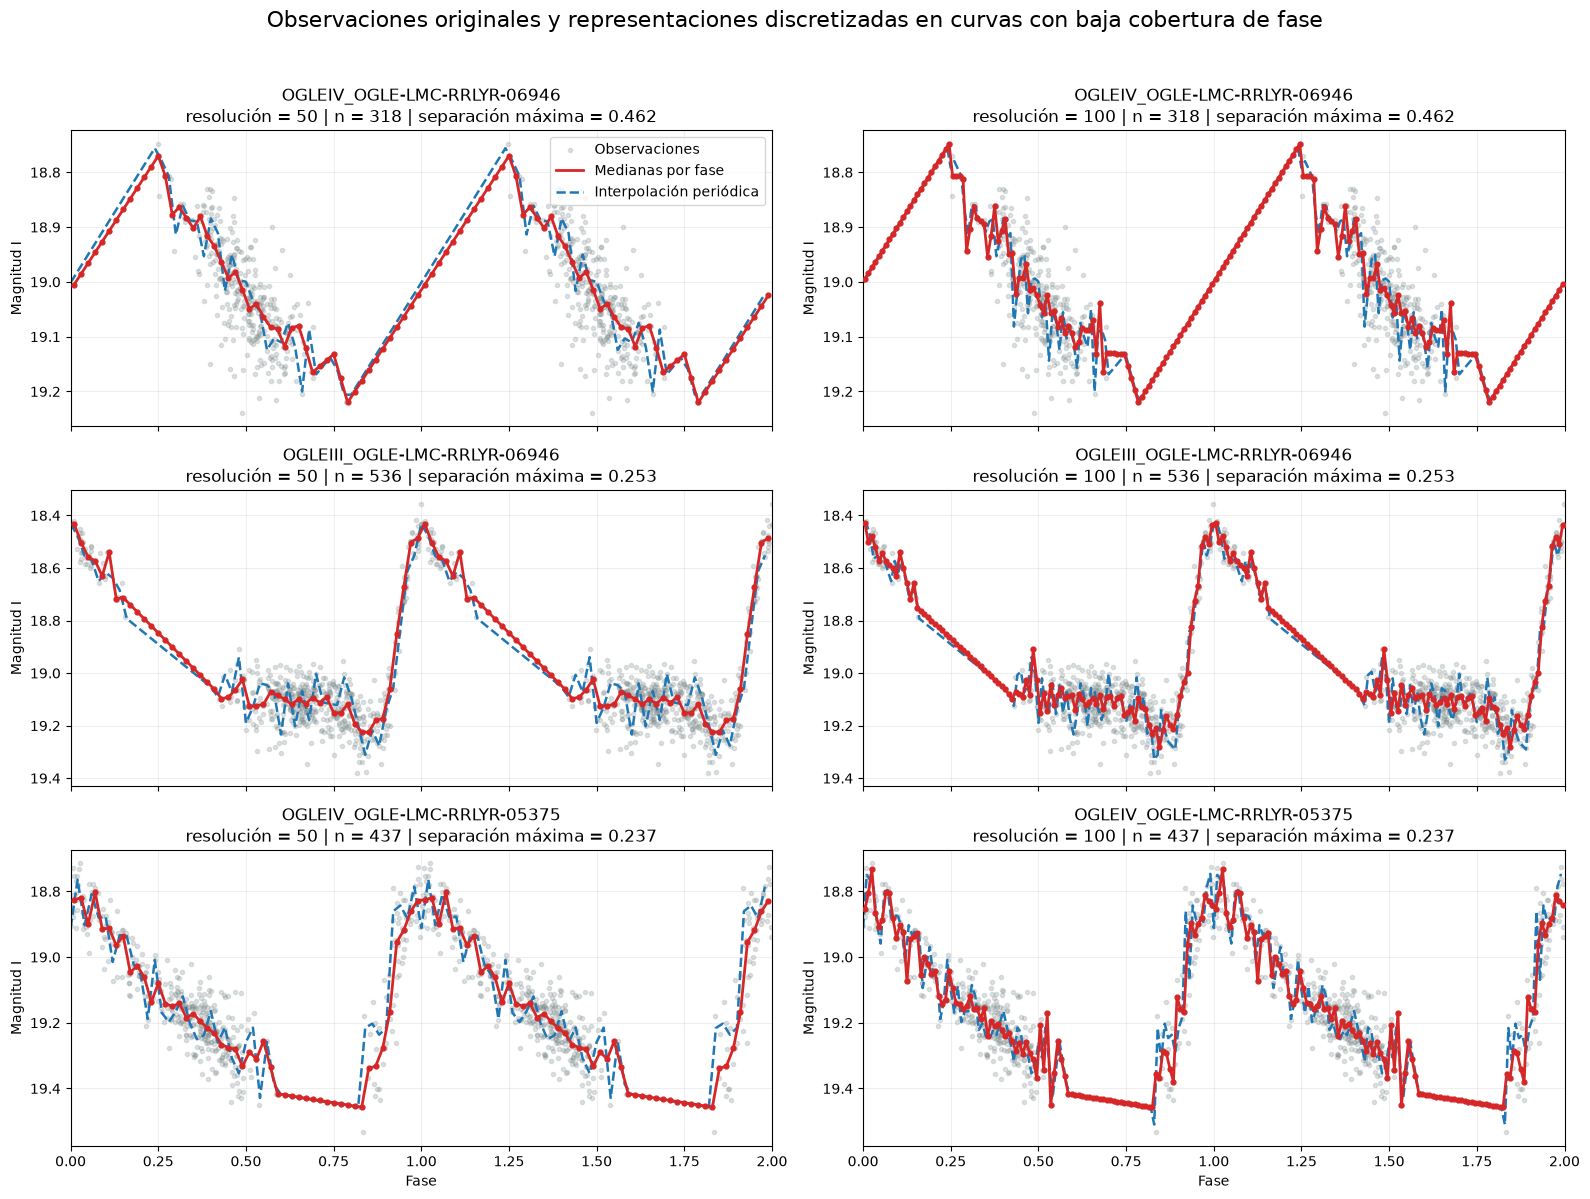

Parquet utilizado: C:\Users\adanm\Code\tesis\data\interim\curvas_plegadas_final.parquet
Curvas representadas: ['OGLEIV_OGLE-LMC-RRLYR-06946', 'OGLEIII_OGLE-LMC-RRLYR-06946', 'OGLEIV_OGLE-LMC-RRLYR-05375']
Figura guardada en: C:\Users\adanm\Code\tesis\reports\figures\comparacion_reconstrucciones_curvas_extremas.png


In [16]:
# ============================================================
# Comparación visual entre las observaciones originales y las
# cuatro representaciones discretizadas
# ============================================================

# Esta celda utiliza exclusivamente los archivos finales.
# No depende de la ruta que haya quedado activa en otras celdas.

ruta_curvas_finales = Path(
    "../data/interim/curvas_plegadas_final.parquet"
)

directorio_discretizaciones = Path(
    "../data/processed/discretizaciones"
)

rutas_discretizaciones = {
    ("medianas_fase", 50): (
        directorio_discretizaciones
        / "medianas_fase_50.parquet"
    ),
    ("medianas_fase", 100): (
        directorio_discretizaciones
        / "medianas_fase_100.parquet"
    ),
    ("interpolacion", 50): (
        directorio_discretizaciones
        / "interpolacion_50.parquet"
    ),
    ("interpolacion", 100): (
        directorio_discretizaciones
        / "interpolacion_100.parquet"
    ),
}

directorio_figuras = Path(
    "../reports/figures"
)

directorio_figuras.mkdir(
    parents=True,
    exist_ok=True,
)

ruta_figura = (
    directorio_figuras
    / "comparacion_reconstrucciones_curvas_extremas.png"
)

# ------------------------------------------------------------
# Verificación de archivos
# ------------------------------------------------------------

archivos_requeridos = [
    ruta_curvas_finales,
    *rutas_discretizaciones.values(),
]

archivos_faltantes = [
    ruta
    for ruta in archivos_requeridos
    if not ruta.exists()
]

if archivos_faltantes:
    detalle = "\n".join(
        str(ruta)
        for ruta in archivos_faltantes
    )

    raise FileNotFoundError(
        "No se encontraron los siguientes archivos:\n"
        f"{detalle}"
    )

# ------------------------------------------------------------
# Selección de las tres curvas con mayor separación de fase
# ------------------------------------------------------------

columnas_auditoria_requeridas = {
    "observacion_id",
    "separacion_fase_maxima",
}

if "auditoria_detallada" not in globals():
    raise NameError(
        "No existe la tabla 'auditoria_detallada'. "
        "Ejecuta primero la celda de auditoría global "
        "de cobertura de fase."
    )

columnas_auditoria_faltantes = (
    columnas_auditoria_requeridas
    - set(auditoria_detallada.columns)
)

if columnas_auditoria_faltantes:
    raise ValueError(
        "La tabla 'auditoria_detallada' no contiene "
        "las columnas requeridas: "
        f"{sorted(columnas_auditoria_faltantes)}"
    )

ids_extremos = (
    auditoria_detallada
    .sort_values(
        "separacion_fase_maxima",
        ascending=False,
    )
    ["observacion_id"]
    .drop_duplicates()
    .head(3)
    .tolist()
)

if len(ids_extremos) != 3:
    raise ValueError(
        "No fue posible seleccionar tres curvas extremas."
    )

# ------------------------------------------------------------
# Lectura de las curvas originales desde el Parquet final
# ------------------------------------------------------------

archivo_curvas_finales = pq.ParquetFile(
    ruta_curvas_finales
)

curvas_originales = {}

for numero_grupo in range(
    archivo_curvas_finales.num_row_groups
):
    tabla_grupo = archivo_curvas_finales.read_row_group(
        numero_grupo,
        columns=[
            "observacion_id",
            "fase",
            "magnitud",
        ],
    )

    for curva in tabla_grupo.to_pylist():
        observacion_id = curva["observacion_id"]

        if observacion_id in ids_extremos:
            curvas_originales[observacion_id] = {
                "fase": np.asarray(
                    curva["fase"],
                    dtype=np.float64,
                ),
                "magnitud": np.asarray(
                    curva["magnitud"],
                    dtype=np.float64,
                ),
            }

    if len(curvas_originales) == len(ids_extremos):
        break

ids_no_encontrados = (
    set(ids_extremos)
    - set(curvas_originales)
)

if ids_no_encontrados:
    raise ValueError(
        "No se encontraron en el Parquet final las curvas: "
        f"{sorted(ids_no_encontrados)}"
    )

# ------------------------------------------------------------
# Lectura de las representaciones discretizadas
# ------------------------------------------------------------

representaciones = {}

for clave, ruta_dataset in rutas_discretizaciones.items():

    dataset = pd.read_parquet(
        ruta_dataset
    )

    if "observacion_id" not in dataset.columns:
        raise ValueError(
            f"El archivo {ruta_dataset.name} no contiene "
            "la columna 'observacion_id'."
        )

    subconjunto = (
        dataset[
            dataset["observacion_id"].isin(ids_extremos)
        ]
        .set_index("observacion_id")
    )

    ids_faltantes_dataset = (
        set(ids_extremos)
        - set(subconjunto.index)
    )

    if ids_faltantes_dataset:
        raise ValueError(
            f"Faltan observaciones en {ruta_dataset.name}: "
            f"{sorted(ids_faltantes_dataset)}"
        )

    columnas_magnitud = sorted(
        [
            columna
            for columna in subconjunto.columns
            if columna.startswith("magnitud_")
        ]
    )

    resolucion = clave[1]

    if len(columnas_magnitud) != resolucion:
        raise ValueError(
            f"{ruta_dataset.name} contiene "
            f"{len(columnas_magnitud)} características, "
            f"pero se esperaban {resolucion}."
        )

    representaciones[clave] = {
        observacion_id: (
            subconjunto
            .loc[observacion_id, columnas_magnitud]
            .to_numpy(dtype=np.float64)
        )
        for observacion_id in ids_extremos
    }

# ------------------------------------------------------------
# Construcción de la figura
# ------------------------------------------------------------

figura, ejes = plt.subplots(
    nrows=len(ids_extremos),
    ncols=2,
    figsize=(16, 12),
    sharex=True,
)

colores = {
    "observaciones": "#7f8c8d",
    "medianas_fase": "#d62728",
    "interpolacion": "#1f77b4",
}

for indice_fila, observacion_id in enumerate(
    ids_extremos
):

    fase_original = curvas_originales[
        observacion_id
    ]["fase"]

    magnitud_original = curvas_originales[
        observacion_id
    ]["magnitud"]

    # Las observaciones se duplican únicamente para visualizar
    # dos ciclos consecutivos.
    fase_original_doble = np.concatenate([
        fase_original,
        fase_original + 1.0,
    ])

    magnitud_original_doble = np.concatenate([
        magnitud_original,
        magnitud_original,
    ])

    separacion_maxima = float(
        auditoria_detallada.loc[
            auditoria_detallada["observacion_id"]
            == observacion_id,
            "separacion_fase_maxima",
        ].max()
    )

    for indice_columna, resolucion in enumerate(
        [50, 100]
    ):

        eje = ejes[
            indice_fila,
            indice_columna,
        ]

        valores_medianas = representaciones[
            ("medianas_fase", resolucion)
        ][observacion_id]

        valores_interpolacion = representaciones[
            ("interpolacion", resolucion)
        ][observacion_id]

        # Las medianas representan el centro de cada intervalo.
        fases_medianas = (
            np.arange(
                resolucion,
                dtype=np.float64,
            )
            + 0.5
        ) / resolucion

        # La interpolación utiliza una grilla que comienza en fase 0
        # y excluye el extremo 1.
        fases_interpolacion = (
            np.arange(
                resolucion,
                dtype=np.float64,
            )
            / resolucion
        )

        fases_medianas_dobles = np.concatenate([
            fases_medianas,
            fases_medianas + 1.0,
        ])

        valores_medianas_dobles = np.concatenate([
            valores_medianas,
            valores_medianas,
        ])

        fases_interpolacion_dobles = np.concatenate([
            fases_interpolacion,
            fases_interpolacion + 1.0,
        ])

        valores_interpolacion_dobles = np.concatenate([
            valores_interpolacion,
            valores_interpolacion,
        ])

        eje.scatter(
            fase_original_doble,
            magnitud_original_doble,
            s=9,
            alpha=0.25,
            color=colores["observaciones"],
            label="Observaciones",
            rasterized=True,
            zorder=1,
        )

        eje.plot(
            fases_medianas_dobles,
            valores_medianas_dobles,
            color=colores["medianas_fase"],
            linewidth=2.0,
            label="Medianas por fase",
            zorder=3,
        )

        eje.scatter(
            fases_medianas_dobles,
            valores_medianas_dobles,
            s=12,
            color=colores["medianas_fase"],
            zorder=4,
        )

        eje.plot(
            fases_interpolacion_dobles,
            valores_interpolacion_dobles,
            color=colores["interpolacion"],
            linewidth=1.8,
            linestyle="--",
            label="Interpolación periódica",
            zorder=2,
        )

        eje.set_xlim(
            0.0,
            2.0,
        )

        # En magnitudes astronómicas, los valores menores
        # corresponden a mayor brillo.
        eje.invert_yaxis()

        eje.grid(
            alpha=0.2,
        )

        eje.set_title(
            f"{observacion_id}\n"
            f"resolución = {resolucion} | "
            f"n = {len(fase_original):,} | "
            f"separación máxima = {separacion_maxima:.3f}"
        )

        eje.set_ylabel(
            "Magnitud I"
        )

        if indice_fila == len(ids_extremos) - 1:
            eje.set_xlabel(
                "Fase"
            )

        if (
            indice_fila == 0
            and indice_columna == 0
        ):
            eje.legend(
                loc="best",
                frameon=True,
            )

figura.suptitle(
    "Observaciones originales y representaciones discretizadas "
    "en curvas con baja cobertura de fase",
    fontsize=16,
    y=0.995,
)

figura.tight_layout(
    rect=[
        0.0,
        0.0,
        1.0,
        0.975,
    ]
)

figura.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Parquet utilizado:",
    ruta_curvas_finales.resolve(),
)

print(
    "Curvas representadas:",
    ids_extremos,
)

print(
    "Figura guardada en:",
    ruta_figura.resolve(),
)